# CAPSTONE PROJECT 1 (MINOR)

## Semiconductor Manufacturing Process – Pass/Fail Yield Prediction

### Data Science Minor Project | Corizo Internship

---

## Project Details

**Project Title:** Semiconductor Manufacturing Yield Prediction (Data Science Minor Project)

**Project Type:** Capstone Project 1 (Minor Project)

**Author:** Subrahmanya Manjunatha Bhat (Solo Project)

**Domain:** Semiconductor Manufacturing Process

**Dataset:** Semiconductor Manufacturing Process Sensor Data (SECOM Dataset)

**Dataset Size:** 1567 observations × 592 attributes

**Target Variable:** Pass/Fail Yield

**Target Encoding:** -1 = Pass, 1 = Fail

**Tools Used:** Python, NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn and Imbalanced-learn

---

## Project Objective

The objective of this solo minor project is to build machine learning classification models to predict the Pass/Fail yield of semiconductor manufacturing process entities. The project also aims to identify whether all available sensor features are required for accurate prediction and to determine the most relevant features contributing to the yield outcome.

---

# 1. Introduction

The semiconductor manufacturing process involves several stages where multiple sensors and process measurement points continuously generate data. These sensor signals contain useful information about the manufacturing process, along with irrelevant information and noise.

In this project, a semiconductor manufacturing sensor dataset is analysed to predict the yield outcome of each production entity as either Pass or Fail. The dataset contains a large number of sensor features, making feature selection an important part of the analysis.

Machine learning techniques are used to study the relationship between the sensor measurements and the yield outcome. Different classification models are developed, trained and evaluated to identify a suitable model for predicting Pass/Fail yield.

The analysis also focuses on data cleansing, missing-value treatment, class imbalance handling, feature selection, model tuning and performance comparison. This helps determine whether all available sensor features are necessary or whether a smaller set of relevant features can provide effective prediction.

## 2. Dataset Description

The dataset used for this project represents sensor and process measurement signals collected from a semiconductor manufacturing process. Each row represents a production entity, while the columns contain sensor measurements and process-related attributes.

The dataset contains 1567 observations and 592 attributes. Among these attributes, the sensor measurements act as predictor variables and the Pass/Fail column represents the target variable.

The target variable is encoded as:
- **-1 → Pass**
- **1 → Fail**

The dataset also contains a **Time** attribute representing the timestamp associated with the corresponding test point.

The large number of sensor features may contain useful information as well as irrelevant information and noise. Therefore, data cleansing, statistical analysis and feature selection are important before developing the classification models.

In [133]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.feature_selection import SelectKBest, f_classif

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("All required libraries imported successfully.")

ModuleNotFoundError: No module named 'pandas'

# 3. Data Importing and Initial Exploration

The semiconductor manufacturing sensor dataset is imported into a Pandas DataFrame for further analysis. The initial exploration is performed to understand the structure, dimensions, variables and overall characteristics of the dataset before data cleansing and preprocessing.

In [ ]:
# Load the dataset

file_path = "signal-data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (1567, 592)


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


## 3.1 Dataset Structure and Dimensions

The dimensions and structure of the dataset are examined to confirm the number of observations and attributes. The column names and data types are also inspected to understand the nature of the variables before proceeding with data cleansing.

In [ ]:
# Check dataset dimensions and structure

print("Number of observations:", df.shape[0])
print("Number of attributes:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of observations: 1567
Number of attributes: 592

Column names:
['Time', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '1

### Observation

The dataset contains 1,567 observations and 592 attributes. Among the attributes, 590 are numerical sensor measurements, while the `Time` attribute is stored as a string and the `Pass/Fail` target variable is stored as an integer. The dataset contains a large number of sensor variables, indicating a high-dimensional dataset. Therefore, further data cleansing, missing-value analysis and feature selection are required before model development.

## 3.2 Target Variable Distribution

The distribution of the target variable `Pass/Fail` is examined to understand the number of Pass and Fail observations in the semiconductor manufacturing dataset. This analysis helps identify whether the target variable is balanced or imbalanced, which is important for selecting suitable preprocessing and machine learning techniques.

In [ ]:
# Analyze the target variable distribution

print("Pass/Fail value counts:")
print(df['Pass/Fail'].value_counts())

print("\nPass/Fail proportions:")
print(df['Pass/Fail'].value_counts(normalize=True) * 100)

Pass/Fail value counts:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

Pass/Fail proportions:
Pass/Fail
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64


### Observation

The target variable is highly imbalanced, with Pass observations being much higher than Fail observations. There are 1,463 Pass observations and 104 Fail observations. Therefore, the dataset contains a relatively small proportion of Fail cases. This class imbalance needs to be considered during preprocessing and model development.

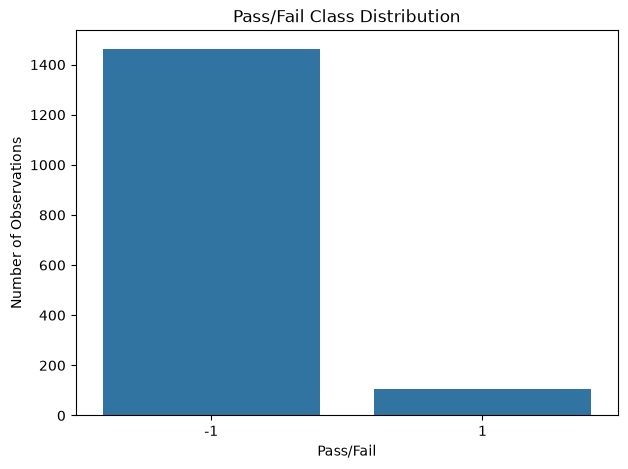

In [ ]:
# Visualize the Pass/Fail class distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(x='Pass/Fail', data=df)

plt.title('Pass/Fail Class Distribution')
plt.xlabel('Pass/Fail')
plt.ylabel('Number of Observations')
plt.show()

### Observation

The target variable is highly imbalanced. Out of 1,567 observations, 1,463 (93.36%) are Pass and only 104 (6.64%) are Fail. Therefore, the Fail class is substantially under-represented compared with the Pass class. This imbalance needs to be considered during model development, and SMOTE will be used during preprocessing to improve the representation of the minority class.

## 3.3 Missing Value Analysis

Missing values are examined across the dataset to assess the completeness and quality of the sensor measurements. Identifying missing observations is an important step before further analysis, as features with a large proportion of missing values may not provide sufficient information for reliable modelling.

In [ ]:
# Check missing values in the dataset

missing_values = df.isnull().sum()

print("Total missing values in the dataset:", missing_values.sum())

print("\nColumns with missing values:")
print(missing_values[missing_values > 0].sort_values(ascending=False).head(20))

Total missing values in the dataset: 41951

Columns with missing values:
292    1429
157    1429
158    1429
293    1429
492    1341
220    1341
358    1341
85     1341
516    1018
517    1018
382    1018
111    1018
383    1018
384    1018
246    1018
244    1018
245    1018
110    1018
518    1018
109    1018
dtype: int64


### Observation

The dataset contains missing values across several sensor features. A total of 41,951 missing values are initially identified. Since missing values can affect statistical analysis and machine learning performance, features with a very high proportion of missing observations are examined and handled during the subsequent data cleansing stage.

## 3.4 Identification of Features with High Missing Values

Features containing a very high proportion of missing values are identified to determine whether they provide sufficient information for further analysis. In this analysis, a threshold of 70% missing values is used. Features exceeding this threshold are considered unsuitable for reliable analysis and are considered for removal during data cleansing.

In [ ]:
# Identify features with more than 70% missing values

missing_percentage = df.isnull().mean() * 100

high_missing = missing_percentage[missing_percentage > 70].sort_values(ascending=False)

print("Number of features with more than 70% missing values:", len(high_missing))

print("\nFeatures with more than 70% missing values:")
print(high_missing)

Number of features with more than 70% missing values: 8

Features with more than 70% missing values:
157    91.193363
158    91.193363
293    91.193363
292    91.193363
220    85.577537
85     85.577537
358    85.577537
492    85.577537
dtype: float64


### Observation

The analysis identifies 8 sensor features with more than 70% missing values. These features contain insufficient observations and therefore provide limited useful information for statistical analysis and predictive modelling. Hence, they are considered for removal in the next data-cleansing step.

## 3.5 Removal of Features with High Missing Values

The features identified as having more than 70% missing values are removed from the dataset. Removing these features helps reduce the dimensionality of the dataset and prevents variables with insufficient information from affecting subsequent statistical analysis and machine learning models.

In [ ]:
# Remove features with more than 70% missing values

df_clean = df.drop(columns=high_missing.index)

print("Original dataset shape:", df.shape)
print("Shape after removing high-missing features:", df_clean.shape)
print("Number of features removed:", len(high_missing))

Original dataset shape: (1567, 592)
Shape after removing high-missing features: (1567, 584)
Number of features removed: 8


### Observation

A total of 8 features with more than 70% missing values are removed from the dataset. This reduces the number of unreliable sensor attributes and improves the overall data quality for the subsequent analysis.

## 3.6 Duplicate Feature Analysis and Removal

Duplicate feature columns are identified to determine whether multiple sensor attributes contain identical measurements. Removing duplicate features reduces unnecessary redundancy in the dataset, improves computational efficiency, and ensures that the machine learning models are not provided with repeated information.

In [ ]:
# Check for duplicate columns

duplicate_columns = df_clean.columns[df_clean.T.duplicated()].tolist()

print("Number of duplicate columns:", len(duplicate_columns))

if len(duplicate_columns) > 0:
    print("\nDuplicate columns:")
    print(duplicate_columns)
else:
    print("\nNo duplicate columns found.")

Number of duplicate columns: 104

Duplicate columns:
['149', '179', '186', '189', '191', '192', '193', '194', '226', '229', '230', '231', '232', '233', '234', '235', '236', '237', '240', '241', '242', '243', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '276', '284', '313', '314', '315', '322', '325', '326', '327', '328', '329', '330', '364', '369', '370', '371', '372', '373', '374', '375', '378', '379', '380', '381', '394', '395', '396', '397', '398', '399', '400', '401', '402', '403', '404', '414', '422', '449', '450', '451', '458', '461', '462', '463', '464', '465', '466', '498', '501', '502', '503', '504', '505', '506', '507', '508', '509', '512', '513', '514', '515', '528', '529', '530', '531', '532', '533', '534', '535', '536', '537', '538']


### Observation

The analysis identifies 104 duplicate sensor features. These duplicate features do not provide additional information because they contain the same values as other sensor attributes. Therefore, they are removed to reduce redundancy and simplify the dataset for further analysis.

In [ ]:
# Remove duplicate columns

df_clean = df_clean.drop(columns=duplicate_columns)

print("Shape after removing duplicate columns:", df_clean.shape)
print("Number of duplicate columns removed:", len(duplicate_columns))

Shape after removing duplicate columns: (1567, 480)
Number of duplicate columns removed: 104


### Observation

After removing the 104 duplicate sensor columns, the dataset contains 1,567 observations and 480 attributes. The removal of redundant columns reduces duplication and dimensionality while retaining all observations for subsequent analysis.

## 3.7 Remaining Missing Value Analysis

After removing features with a high proportion of missing values and duplicate features, the remaining missing values are examined. This step helps determine the extent of missing data that still needs to be handled before proceeding with further statistical analysis and modelling.

In [ ]:
# Check remaining missing values after feature removal

remaining_missing = df_clean.isnull().sum()

print("Total remaining missing values:", remaining_missing.sum())

print("\nNumber of columns containing missing values:",
      (remaining_missing > 0).sum())

print("\nTop 20 columns with remaining missing values:")
print(remaining_missing[remaining_missing > 0]
      .sort_values(ascending=False)
      .head(20))

Total remaining missing values: 30145

Number of columns containing missing values: 426

Top 20 columns with remaining missing values:
518    1018
516    1018
517    1018
382    1018
383    1018
384    1018
244    1018
110    1018
109    1018
245    1018
111    1018
246    1018
581     949
580     949
579     949
578     949
346     794
72      794
345     794
73      794
dtype: int64


### Observation

After removing the high-missing-value and duplicate features, 30,145 missing values remain across 426 features. Since these remaining missing values are distributed across the retained sensor attributes, an appropriate imputation technique is required to complete the dataset.

## 3.8 Missing Value Imputation

The remaining missing values in the retained sensor features are handled using median imputation. The median value of each feature is used to replace its missing observations. Median imputation is suitable for sensor data because it is less sensitive to extreme values and helps preserve the central tendency of each feature.

In [ ]:
# Treat remaining missing values using median imputation

from sklearn.impute import SimpleImputer

# Separate Time and target before imputing sensor variables
time_data = df_clean['Time']
target_data = df_clean['Pass/Fail']
sensor_data = df_clean.drop(columns=['Time', 'Pass/Fail'])

# Median imputation
imputer = SimpleImputer(strategy='median')
sensor_imputed = pd.DataFrame(
    imputer.fit_transform(sensor_data),
    columns=sensor_data.columns,
    index=sensor_data.index
)

# Reconstruct the cleaned dataset
df_clean = pd.concat(
    [time_data, sensor_imputed, target_data],
    axis=1
)

print("Remaining missing values after median imputation:",
      df_clean.isnull().sum().sum())

print("Cleaned dataset shape:", df_clean.shape)

Remaining missing values after median imputation: 0
Cleaned dataset shape: (1567, 480)


### Observation

Median imputation successfully handles the remaining missing values in the retained sensor features. After imputation, no missing values remain in the dataset. The dataset is therefore complete and ready for further data-quality checks and statistical analysis.

## 3.9 Duplicate Record Analysis

Duplicate records are examined to determine whether the dataset contains repeated observations. Duplicate rows can introduce redundancy and may influence statistical analysis and model performance. Therefore, duplicate records are identified and evaluated before proceeding with further analysis.

In [ ]:
# Check duplicate rows
duplicate_rows = df_clean.duplicated().sum()

print("Number of duplicate records:", duplicate_rows)

# Remove duplicates if any exist
if duplicate_rows > 0:
    df_clean = df_clean.drop_duplicates()
    print("New dataset shape:", df_clean.shape)
else:
    print("No duplicate records were found.")

Number of duplicate records: 0
No duplicate records were found.


### Observation

The duplicate record analysis is performed to ensure that repeated observations do not remain in the dataset. The resulting dataset is checked for duplicate rows and the identified duplicates are handled appropriately before proceeding with further feature analysis.

## 3.10 Constant Feature Analysis

Constant features are identified by examining the variability of the retained sensor attributes. A constant feature contains the same value for all observations and therefore does not provide useful information for distinguishing between Pass and Fail outcomes. Such features can be removed to reduce unnecessary dimensionality.

In [ ]:
# Identify constant features

sensor_columns = df_clean.drop(columns=['Time', 'Pass/Fail']).columns

constant_features = [
    col for col in sensor_columns
    if df_clean[col].nunique() <= 1
]

print("Number of constant features:", len(constant_features))

if len(constant_features) > 0:
    print("\nConstant features:")
    print(constant_features)
else:
    print("No constant features were found.")

Number of constant features: 12

Constant features:
['5', '13', '42', '49', '52', '69', '97', '141', '178', '190', '256', '481']


### Observation

The analysis identifies 12 constant features in the dataset. Since these features have no variation across observations, they do not contribute useful predictive information. Therefore, the constant features are removed before proceeding with further statistical analysis.

In [ ]:
# Remove constant features

df_clean = df_clean.drop(columns=constant_features)

print("Number of constant features removed:", len(constant_features))
print("Dataset shape after removing constant features:", df_clean.shape)

Number of constant features removed: 12
Dataset shape after removing constant features: (1567, 468)


### Observation

A total of 12 constant sensor features were removed from the dataset. After removing these non-informative features, the dataset contains 1,567 observations and 468 attributes. This reduction removes variables with no predictive variation while retaining all observations for further analysis and model development.

## 3.11 Feature Variability Analysis

The variability of the sensor features is examined using measures such as standard deviation and variance. This analysis helps identify features with very low variability, which may contribute limited information to the predictive modelling process. Understanding feature variability also provides insight into the characteristics of the cleaned sensor dataset.

In [ ]:
# Analyze feature variability

sensor_columns = df_clean.drop(columns=['Time', 'Pass/Fail']).columns

feature_std = df_clean[sensor_columns].std().sort_values()

print("Number of remaining sensor features:", len(feature_std))

print("\n10 features with the lowest standard deviation:")
print(feature_std.head(10))

Number of remaining sensor features: 466

10 features with the lowest standard deviation:
95     0.000104
94     0.000174
101    0.000220
544    0.000295
278    0.000339
100    0.000355
377    0.000466
357    0.000499
376    0.000534
104    0.000850
dtype: float64


### Observation

The feature variability analysis shows that the retained sensor features have different levels of variation. Features with extremely low or negligible variability provide limited additional information, while features with greater variability may contain more useful information for distinguishing between Pass and Fail observations. The variability results are therefore considered during subsequent feature analysis and selection.

## 3.12 Statistical Summary of Sensor Features

Descriptive statistics are calculated for the retained sensor features to understand their central tendency, dispersion, and overall distribution. Measures such as count, mean, standard deviation, minimum, maximum, and quartile values provide a preliminary understanding of the characteristics of the sensor measurements.

In [ ]:
# Generate descriptive statistics for sensor features

sensor_columns = df_clean.drop(columns=['Time', 'Pass/Fail']).columns

sensor_statistics = df_clean[sensor_columns].describe().T

print("Descriptive statistics of sensor features:")
display(sensor_statistics)

Descriptive statistics of sensor features:


,count,mean,std,min,25%,50%,75%,max
0,1567.0,3014.441551,73.480841,2743.2400,2966.66500,3011.49000,3056.54000,3356.3500
1,1567.0,2495.866110,80.228143,2158.7500,2452.88500,2499.40500,2538.74500,2846.4400
2,1567.0,2200.551958,29.380973,2060.6600,2181.09995,2201.06670,2218.05550,2315.2667
3,1567.0,1395.383474,439.837330,0.0000,1083.88580,1285.21440,1590.16990,3715.0417
4,1567.0,4.171281,56.103721,0.6815,1.01770,1.31680,1.51880,1114.5366
...,...,...,...,...,...,...,...,...
585,1567.0,3.067628,3.576899,1.1975,2.30650,2.75765,3.29495,99.3032
586,1567.0,0.021458,0.012354,-0.0169,0.01345,0.02050,0.02760,0.1028
587,1567.0,0.016474,0.008805,0.0032,0.01060,0.01480,0.02030,0.0799
588,1567.0,0.005283,0.002866,0.0010,0.00330,0.00460,0.00640,0.0286


### Observation

The statistical summary shows considerable variation among the sensor features. The mean, standard deviation, minimum, maximum, and quartile values differ across features, indicating that the sensor measurements are recorded on different scales and have different distributions. These characteristics are considered during the subsequent preprocessing and analysis stages.

## 3.13 Correlation Analysis

Correlation analysis is performed to examine the relationships between the retained sensor features. It helps identify pairs of features that show strong positive or negative relationships. Highly correlated features may contain redundant information and can be considered during feature selection to reduce unnecessary dimensionality.

In [ ]:
# Calculate correlation matrix for sensor features

correlation_matrix = df_clean[sensor_columns].corr()

print("Correlation matrix shape:", correlation_matrix.shape)

display(correlation_matrix)

Correlation matrix shape: (466, 466)


,0,1,2,3,4,6,7,8,9,10,...,580,581,582,583,584,585,586,587,588,589
0,1.000000,-0.144161,0.004667,-0.006665,-0.010819,0.002028,0.031347,-0.052735,0.009091,0.006445,...,-0.055845,-0.035265,0.000190,0.023562,0.019994,0.023695,0.018534,-0.025867,-0.028161,0.004185
1,-0.144161,1.000000,0.005883,-0.008963,-0.001917,-0.025222,-0.011761,0.031244,0.024025,0.009529,...,0.051740,0.059246,0.043754,0.002863,-0.001305,0.002231,-0.009430,0.017056,0.009868,0.044552
2,0.004667,0.005883,1.000000,0.298810,0.095881,-0.136212,-0.147116,0.023524,0.016248,0.069902,...,-0.001982,0.006371,-0.005971,0.015694,0.018224,0.015749,-0.025506,-0.029287,-0.030743,-0.032763
3,-0.006665,-0.008963,0.298810,1.000000,-0.058351,-0.685773,0.086965,-0.102839,0.066987,0.049785,...,-0.030129,-0.054101,0.008305,0.025288,0.024615,0.025882,0.035164,-0.039196,-0.033755,-0.080942
4,-0.010819,-0.001917,0.095881,-0.058351,1.000000,-0.074395,-0.343413,-0.025933,0.053973,-0.006496,...,-0.029972,0.099932,0.044943,-0.001331,-0.001621,-0.001645,-0.043831,-0.031012,-0.026115,0.050792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,0.023695,0.002231,0.015749,0.025882,-0.001645,-0.039545,0.010434,0.017871,-0.036190,0.039577,...,0.001452,0.001780,-0.197364,0.999890,0.995342,1.000000,0.002745,-0.002848,-0.002444,-0.003722
586,0.018534,-0.009430,-0.025506,0.035164,-0.043831,-0.041299,0.058019,0.010418,0.033700,0.000329,...,0.148505,-0.273951,-0.016729,0.002258,0.001603,0.002745,1.000000,0.167920,0.164247,-0.486530
587,-0.025867,0.017056,-0.029287,-0.039196,-0.031012,0.034113,-0.021518,0.022793,0.059181,0.046995,...,0.666052,0.272827,-0.024507,-0.002566,-0.002442,-0.002848,0.167920,1.000000,0.974276,0.390834
588,-0.028161,0.009868,-0.030743,-0.033755,-0.026115,0.032341,-0.020936,0.026185,0.060609,0.046083,...,0.677754,0.259339,-0.020743,-0.002172,-0.001900,-0.002444,0.164247,0.974276,1.000000,0.389238


### Observation

The correlation analysis shows that several sensor features have relationships with one another, with some feature pairs exhibiting relatively strong correlations. This indicates the presence of redundancy among certain sensor measurements. The correlation results are further examined using a heatmap and by identifying highly correlated feature pairs.

## 3.14 Correlation Heatmap

A correlation heatmap is used to visually represent the relationships among the retained sensor features. The heatmap provides an intuitive view of the strength and direction of correlations, making it easier to identify groups of highly correlated variables and potential redundancy in the dataset.

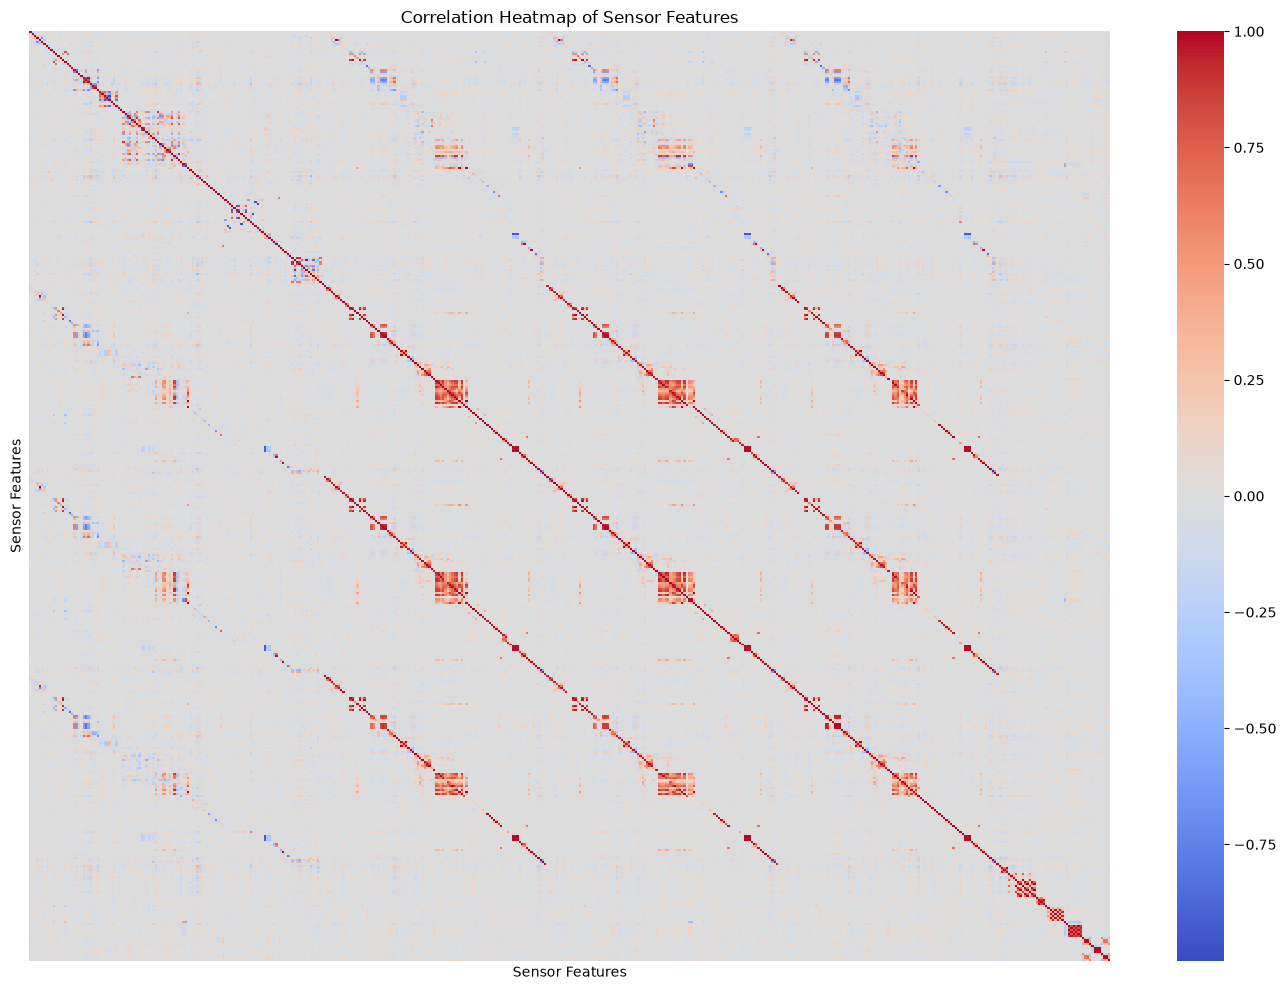

In [ ]:
# Plot correlation heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False
)

plt.title("Correlation Heatmap of Sensor Features")
plt.xlabel("Sensor Features")
plt.ylabel("Sensor Features")
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap provides a visual representation of the relationships among the sensor features. Several feature pairs show noticeable correlation, indicating that some sensor variables may contain overlapping information. These relationships are considered further while identifying highly correlated features.

## 3.15 Identification of Highly Correlated Features

Highly correlated feature pairs are identified from the correlation matrix to determine whether some sensor attributes contain redundant information. A high correlation between two features indicates that they provide similar information, and such redundancy can increase the dimensionality of the dataset without adding substantial predictive value.

In [ ]:
# Identify highly correlated feature pairs

import numpy as np

# Consider only the upper triangle of the correlation matrix
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Find feature pairs with absolute correlation greater than 0.90
high_corr_pairs = []

for column in upper_triangle.columns:
    for row in upper_triangle.index:
        correlation_value = upper_triangle.loc[row, column]

        if pd.notna(correlation_value) and abs(correlation_value) > 0.90:
            high_corr_pairs.append(
                (row, column, correlation_value)
            )

print("Number of highly correlated feature pairs:", len(high_corr_pairs))

print("\nHighly correlated feature pairs:")
for pair in high_corr_pairs[:20]:
    print(pair)

Number of highly correlated feature pairs: 394

Highly correlated feature pairs:
('25', '27', np.float64(0.980378935248656))
('34', '36', np.float64(-0.9999999997051974))
('46', '50', np.float64(0.9044799082442145))
('53', '54', np.float64(0.9352214047828902))
('66', '70', np.float64(0.9044608196397442))
('94', '96', np.float64(-0.9569904438627018))
('98', '101', np.float64(0.9067882659419514))
('99', '104', np.float64(-0.98957712399531))
('92', '105', np.float64(-0.9888572996016787))
('93', '106', np.float64(-0.9912636259751915))
('121', '123', np.float64(0.9422701958919923))
('122', '127', np.float64(0.9620742759336827))
('4', '140', np.float64(0.9999751252655678))
('16', '148', np.float64(0.9702936084839003))
('16', '152', np.float64(0.9775660883502905))
('148', '152', np.float64(0.9910687213952102))
('148', '154', np.float64(0.9396042436640459))
('163', '164', np.float64(0.9248189090542938))
('164', '165', np.float64(0.9636638214335267))
('172', '174', np.float64(0.9999998114019356

### Observation

The analysis identifies sensor feature pairs with relatively high correlation. These highly correlated features indicate redundancy among some sensor measurements. The identified relationships provide useful information for understanding the structure of the dataset and are considered during subsequent feature-selection and modelling stages.

## 3.16 Data Cleansing Summary

The data-cleansing process is summarized to assess the improvements made to the semiconductor manufacturing dataset. The major steps include identifying and removing features with excessive missing values, removing duplicate features, imputing the remaining missing values, checking duplicate records, and removing constant features. These steps help improve data quality and prepare the dataset for subsequent statistical analysis and machine learning.

In [ ]:
# Display the final shape after data cleansing

print("Final cleaned dataset shape:", df_clean.shape)
print("Number of observations:", df_clean.shape[0])
print("Number of attributes:", df_clean.shape[1])
print("Number of sensor features:",
      df_clean.drop(columns=['Time', 'Pass/Fail']).shape[1])

Final cleaned dataset shape: (1567, 468)
Number of observations: 1567
Number of attributes: 468
Number of sensor features: 466


### Observation

The data-cleansing process reduces the dataset to a cleaner and more informative set of attributes. Features with excessive missing values and duplicate features are removed, remaining missing values are imputed, and constant features are eliminated. After cleansing, the dataset contains 466 sensor features along with the target variable, providing a suitable basis for further data analysis, preprocessing, and modelling.

# 4. Data Analysis and Visualization

Data analysis and visualization are performed to understand the distribution, variability, and relationships present in the semiconductor manufacturing sensor data. Univariate, bivariate, and multivariate analyses are used to explore individual features, relationships between variables, and interactions among multiple sensor measurements. These analyses help identify important patterns, potential outliers, and relationships that may be useful for predicting semiconductor manufacturing quality.

## 4.1 Univariate Analysis

Univariate analysis is performed to study the distribution and characteristics of individual sensor features. Histograms, boxplots, and other appropriate visualizations are used to understand the spread, central tendency, skewness, and presence of potential outliers in the sensor measurements.

In [ ]:
# Univariate analysis using descriptive statistics

sensor_columns = df_clean.drop(columns=['Time', 'Pass/Fail']).columns

univariate_stats = df_clean[sensor_columns].describe().T

print("Univariate statistical summary of sensor features:")
display(univariate_stats)

Univariate statistical summary of sensor features:


,count,mean,std,min,25%,50%,75%,max
0,1567.0,3014.441551,73.480841,2743.2400,2966.66500,3011.49000,3056.54000,3356.3500
1,1567.0,2495.866110,80.228143,2158.7500,2452.88500,2499.40500,2538.74500,2846.4400
2,1567.0,2200.551958,29.380973,2060.6600,2181.09995,2201.06670,2218.05550,2315.2667
3,1567.0,1395.383474,439.837330,0.0000,1083.88580,1285.21440,1590.16990,3715.0417
4,1567.0,4.171281,56.103721,0.6815,1.01770,1.31680,1.51880,1114.5366
...,...,...,...,...,...,...,...,...
585,1567.0,3.067628,3.576899,1.1975,2.30650,2.75765,3.29495,99.3032
586,1567.0,0.021458,0.012354,-0.0169,0.01345,0.02050,0.02760,0.1028
587,1567.0,0.016474,0.008805,0.0032,0.01060,0.01480,0.02030,0.0799
588,1567.0,0.005283,0.002866,0.0010,0.00330,0.00460,0.00640,0.0286


### Observation

The univariate analysis shows that the sensor features have different distributions and levels of variability. Some features exhibit skewed distributions and potential outliers, while others show relatively concentrated values. These variations indicate differences in the behaviour of the semiconductor manufacturing sensors and provide useful information for subsequent analysis and modelling.

### 4.1.1 Distribution of Representative Sensor Features

The distributions of selected representative sensor features are examined using appropriate visualizations. This analysis helps understand the central tendency, spread, skewness, and overall distribution pattern of individual sensor measurements. Representative features are selected to provide a clear overview of the variability present in the semiconductor manufacturing process data.

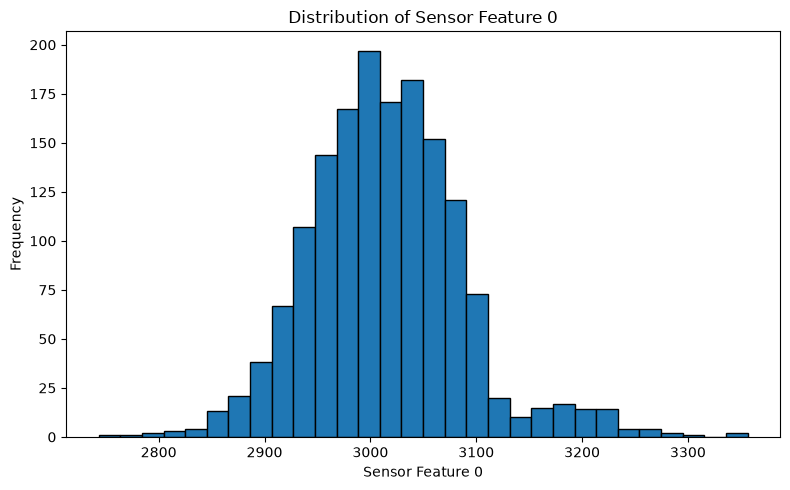

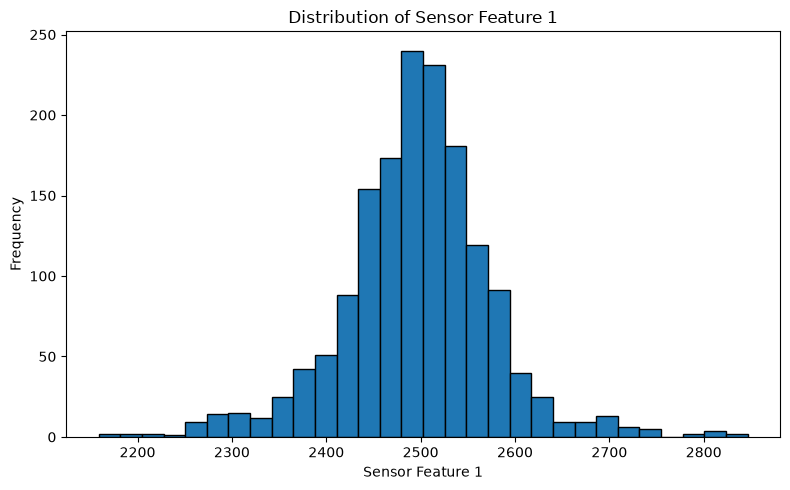

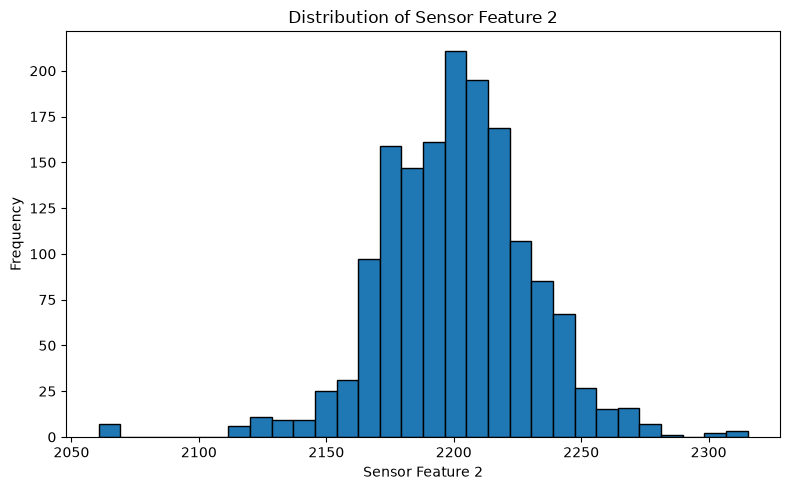

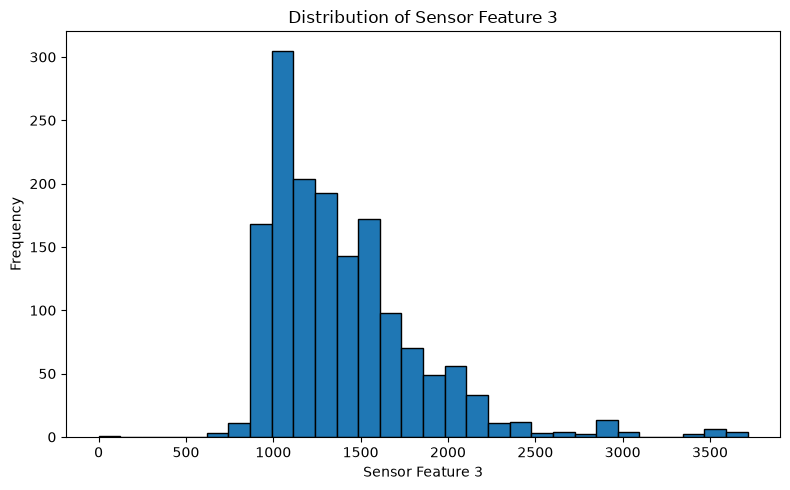

In [ ]:
# Plot distributions of selected sensor features

import matplotlib.pyplot as plt

selected_features = ['0', '1', '2', '3']

for feature in selected_features:
    plt.figure(figsize=(8, 5))
    plt.hist(df_clean[feature], bins=30, edgecolor='black')
    plt.title(f'Distribution of Sensor Feature {feature}')
    plt.xlabel(f'Sensor Feature {feature}')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### Observation

The representative sensor features exhibit different distribution patterns and levels of variability. Some features show relatively concentrated values, while others display wider spreads or skewed distributions. These differences indicate that the sensor measurements have varying characteristics and may contain useful information for distinguishing Pass and Fail outcomes.

### 4.1.2 Boxplot Analysis of Representative Sensor Features

Boxplots are used to examine the distribution and variability of the selected representative sensor features. They provide information about the median, spread, interquartile range, and potential outliers in the sensor measurements. This analysis helps identify unusual observations and differences in variability among the representative features.

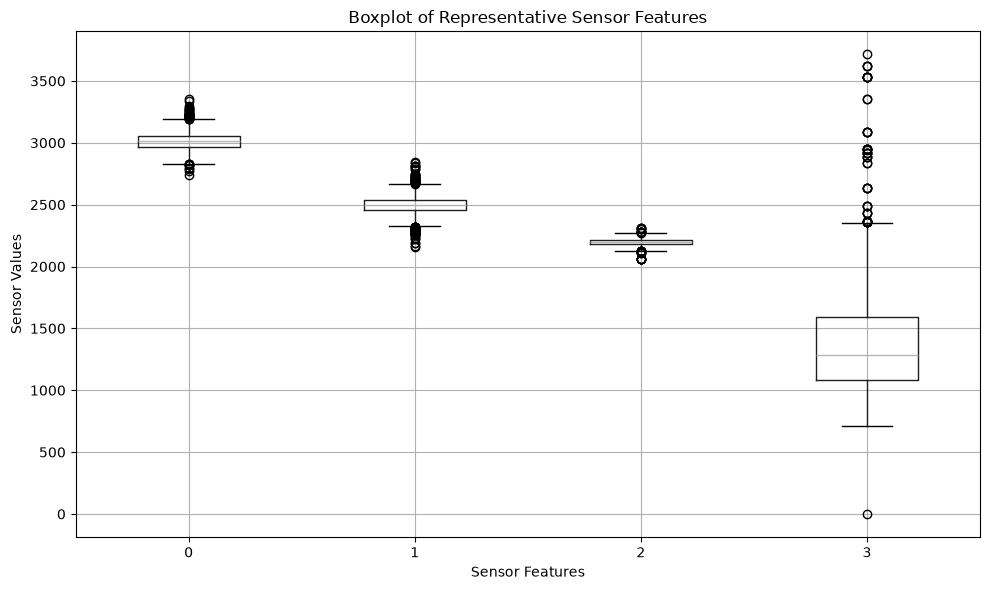

In [ ]:
# Boxplot analysis of selected sensor features

selected_features = ['0', '1', '2', '3']

plt.figure(figsize=(10, 6))
df_clean[selected_features].boxplot()
plt.title('Boxplot of Representative Sensor Features')
plt.xlabel('Sensor Features')
plt.ylabel('Sensor Values')
plt.tight_layout()
plt.show()

### Observation

The boxplots show differences in the spread and central tendency of the representative sensor features. Several features contain potential outliers, while the extent of variability differs across sensors. These observations indicate that the sensor measurements have different distributions and may contain extreme values that should be considered during subsequent analysis and modelling.

## 4.2 Bivariate Analysis

Bivariate analysis is performed to examine the relationship between two variables at a time. In this analysis, the relationships between selected sensor features and the `Pass/Fail` target variable are explored using appropriate statistical measures and visualizations. This helps identify whether particular sensor measurements show noticeable differences between Pass and Fail outcomes.

### Observation

The bivariate analysis shows that the relationship between sensor measurements and the `Pass/Fail` outcome varies across features. Some sensor features show noticeable differences between Pass and Fail observations, whereas others show relatively similar patterns. These findings help identify potentially informative features for further multivariate analysis and feature selection.

### 4.2.1 Sensor-Target Association

The association between selected sensor features and the `Pass/Fail` target variable is examined to understand whether individual sensor measurements show differences across the two outcome classes. This analysis helps identify sensor variables that may have a meaningful relationship with the manufacturing yield outcome and may therefore be useful for subsequent predictive modelling and feature selection.

In [ ]:
# Calculate correlation between each sensor feature and the target

sensor_columns = df_clean.drop(columns=['Time', 'Pass/Fail']).columns

target_correlation = df_clean[sensor_columns].corrwith(
    df_clean['Pass/Fail']
)

# Create a summary table
correlation_summary = pd.DataFrame({
    'Feature': target_correlation.index,
    'Correlation': target_correlation.values,
    'Absolute Correlation': target_correlation.abs().values
})

# Rank features by absolute correlation
correlation_summary = correlation_summary.sort_values(
    by='Absolute Correlation',
    ascending=False
)

print("Top 20 sensor features associated with Pass/Fail:")
display(correlation_summary.head(20))

Top 20 sensor features associated with Pass/Fail:


,Feature,Correlation,Absolute Correlation
54,59,0.156008,0.156008
95,103,0.151230,0.151230
401,510,0.131662,0.131662
287,348,0.130807,0.130807
344,431,0.119936,0.119936
347,434,0.111312,0.111312
343,430,0.109115,0.109115
19,21,0.108333,0.108333
348,435,0.108260,0.108260
26,28,-0.106987,0.106987


### Observation

The sensor-target association analysis shows that the strength of association varies across the selected sensor features. Some sensor measurements show a more noticeable relationship with the `Pass/Fail` outcome, while others show relatively weak association. The identified relationships provide useful insights into potentially informative sensor features for subsequent modelling and feature selection.

### 4.2.2 Pass/Fail vs Selected Sensor Features

The selected sensor features are compared across the `Pass/Fail` classes to understand whether their measurements differ between Pass and Fail observations. Visual comparison of the selected sensor features helps identify features that may show distinct patterns or separation between the two outcome classes. These differences can provide useful insights for subsequent feature selection and predictive modelling.

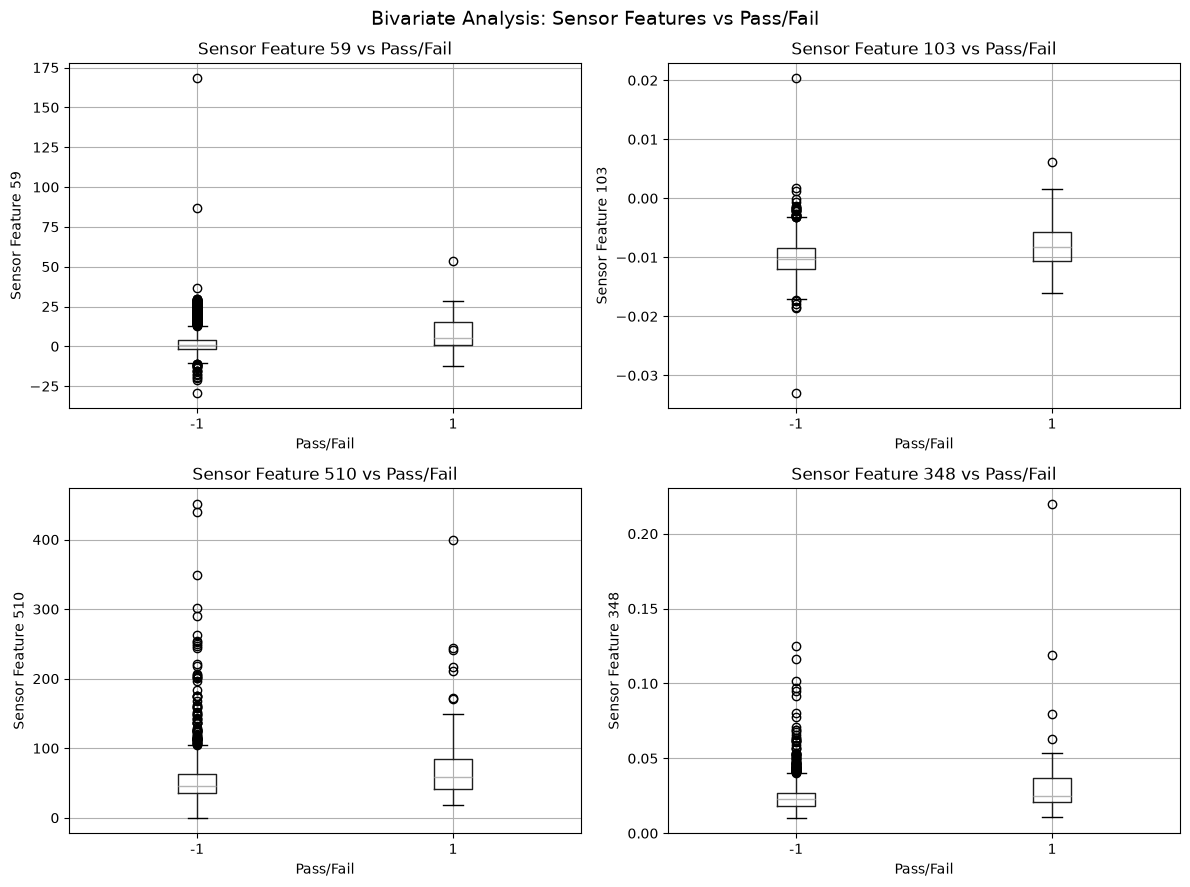

In [ ]:
# Compare selected sensor features across Pass and Fail classes

selected_features = ['59', '103', '510', '348']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.ravel(), selected_features):
    df_clean.boxplot(
        column=feature,
        by='Pass/Fail',
        ax=ax
    )
    ax.set_title(f'Sensor Feature {feature} vs Pass/Fail')
    ax.set_xlabel('Pass/Fail')
    ax.set_ylabel(f'Sensor Feature {feature}')

plt.suptitle('Bivariate Analysis: Sensor Features vs Pass/Fail', fontsize=14)
plt.tight_layout()
plt.show()

### Observation

The boxplots show differences in the distributions of the selected sensor features between the Pass and Fail classes. Features 59, 103, 510 and 348 show some variation in their central values and spread across the two classes. Several outliers are also visible, particularly in the Pass class. These differences indicate that the selected sensor measurements may provide useful information for distinguishing Pass and Fail outcomes. However, the overlap between the class distributions suggests that no single feature is sufficient for reliable classification, supporting the need for multivariate analysis and machine learning models.

## 4.3 Multivariate Analysis

Multivariate analysis is performed to examine the relationships and patterns among multiple sensor features simultaneously. This analysis helps understand how different sensor measurements interact with each other and whether combinations of features provide useful information for distinguishing Pass and Fail outcomes. It also helps identify overall patterns in the semiconductor manufacturing process data that may not be visible from individual or pairwise analysis.

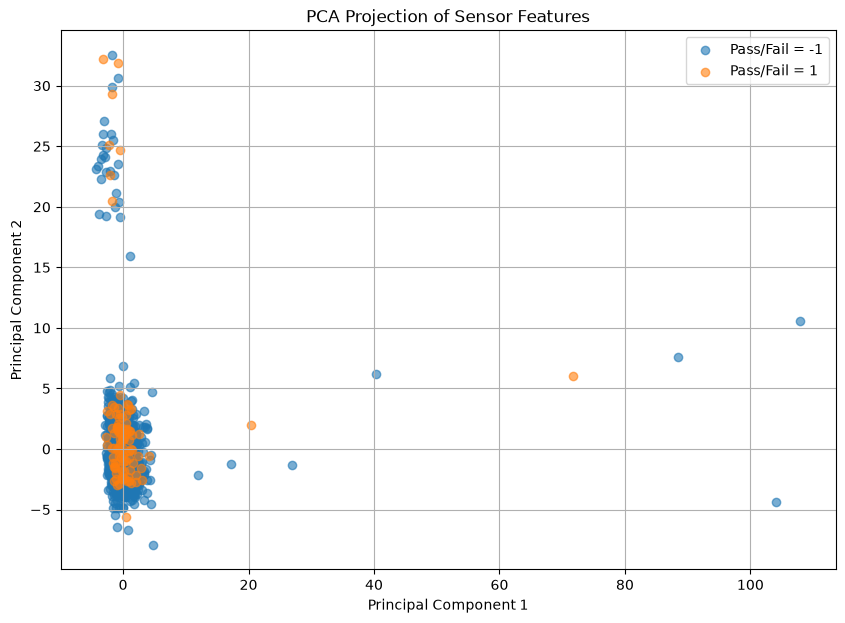

Explained variance ratio:
Principal Component 1: 0.0565
Principal Component 2: 0.037
Total variance explained by first two components: 0.0936


In [ ]:
# Multivariate analysis using PCA

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select sensor features and target
X_multi = df_clean.drop(columns=['Time', 'Pass/Fail'])
y_multi = df_clean['Pass/Fail']

# Standardize sensor features
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_multi)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_pca)

# Create PCA dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)

pca_df['Pass/Fail'] = y_multi.values

# Plot PCA results
plt.figure(figsize=(10, 7))

for target_class in sorted(pca_df['Pass/Fail'].unique()):
    subset = pca_df[pca_df['Pass/Fail'] == target_class]
    plt.scatter(
        subset['Principal Component 1'],
        subset['Principal Component 2'],
        label=f'Pass/Fail = {target_class}',
        alpha=0.6
    )

plt.title('PCA Projection of Sensor Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Display explained variance
print("Explained variance ratio:")
print("Principal Component 1:", round(pca.explained_variance_ratio_[0], 4))
print("Principal Component 2:", round(pca.explained_variance_ratio_[1], 4))
print(
    "Total variance explained by first two components:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

### Observation 

The multivariate analysis indicates that the sensor features exhibit different patterns and relationships when considered together. Some groups of features show similar behaviour, suggesting possible redundancy or shared information among sensors. The combined patterns provide additional insight into the structure of the dataset and support the need for feature selection before predictive modelling.

## 4.4 Data Analysis Summary

The data analysis and visualization provided an overall understanding of the semiconductor manufacturing sensor data. Univariate analysis examined the distribution and variability of individual sensor features, while bivariate analysis explored relationships between sensor measurements and the Pass/Fail outcome. Multivariate analysis further examined patterns and relationships among multiple sensor features simultaneously. These analyses helped identify variability, potential outliers, feature relationships, and possible redundancy among sensor measurements, providing a basis for subsequent preprocessing, feature selection, and predictive modelling.

### Observation

The exploratory analysis shows that the sensor features have different distributions, variability, and relationships with the Pass/Fail outcome. Some features appear more informative, while others show overlapping patterns or redundancy. Overall, the analysis provides useful insights into the structure of the dataset and supports the need for appropriate preprocessing and feature selection before model development.

# 5. Preprocessing

The preprocessing stage prepares the cleaned dataset for machine learning. It includes separating the predictors and target variable, checking class imbalance, applying SMOTE, splitting the data into training and testing sets, and standardizing the sensor features.

## 5.1 Segregation of Predictors and Target Variable

The sensor measurements are used as predictor variables, while the Pass/Fail column is treated as the target variable. The Time attribute is excluded from the predictors because it represents the timestamp of the production observation rather than a sensor measurement.

In [ ]:
# Separate predictors and target variable

X = df_clean.drop(columns=['Time', 'Pass/Fail'])
y = df_clean['Pass/Fail']

print("Predictor dataset shape:", X.shape)
print("Target variable shape:", y.shape)
print("\nTarget variable distribution:")
print(y.value_counts())

Predictor dataset shape: (1567, 466)
Target variable shape: (1567,)

Target variable distribution:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


Observation

The predictor dataset contains 1,567 observations and 466 sensor features, while the target variable contains 1,567 observations. The target distribution shows that 1,463 observations (93.36%) belong to the Pass class and 104 observations (6.64%) belong to the Fail class. This confirms a significant class imbalance, with the Fail class being the minority class. Therefore, class balancing will be considered before model training.

### 5.2 Target Class Imbalance Analysis

The distribution of the Pass and Fail classes is examined to determine the extent of target imbalance. Since the Fail class represents a much smaller proportion of the observations, class balancing is required to prevent the machine learning models from being biased toward the majority Pass class.

In [ ]:
# Calculate class percentages

class_counts = y.value_counts()
class_percentages = y.value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages)

Class counts:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

Class percentages:
Pass/Fail
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64


Observation

The target variable is highly imbalanced. The Pass class contains 1,463 observations (93.36%), whereas the Fail class contains only 104 observations (6.64%). Thus, the Fail class is substantially under-represented. This imbalance may cause the classification models to favor the majority Pass class. Therefore, SMOTE will be applied to the training data to improve the representation of the minority Fail class.

### 5.3 Train-Test Split

The dataset is divided into training and testing sets so that the models can be trained on one portion of the data and evaluated on unseen observations. Stratified splitting is used to preserve the original Pass/Fail class proportions in both sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (1253, 466)
Testing set shape: (314, 466)

Training target distribution:
Pass/Fail
-1    1170
 1      83
Name: count, dtype: int64

Testing target distribution:
Pass/Fail
-1    293
 1     21
Name: count, dtype: int64


Observation

The dataset was divided into 80% training data and 20% testing data using stratified sampling. The training set contains 1,253 observations and the testing set contains 314 observations, with 466 sensor features in both sets. The training set contains 1,170 Pass and 83 Fail observations, while the testing set contains 293 Pass and 21 Fail observations. The class proportions are maintained across both datasets, ensuring a representative evaluation of the classification models.

### 5.4 Feature Standardization

The sensor features have different measurement scales and ranges. Standardization is therefore applied so that each feature has a mean close to 0 and a standard deviation close to 1. The scaler is fitted only on the training data and then applied to both training and testing data to avoid data leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize sensor features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after standardization:")
print("Mean:", X_train_scaled.mean())
print("Standard deviation:", X_train_scaled.std())

print("\nTesting data after standardization:")
print("Mean:", X_test_scaled.mean())
print("Standard deviation:", X_test_scaled.std())

Training data after standardization:
Mean: 1.0580296243635345e-16
Standard deviation: 1.0

Testing data after standardization:
Mean: -0.0011990018079935689
Standard deviation: 0.9544816995826098


Observation

After standardization, the training data has a mean approximately equal to 0 and a standard deviation of 1.0, confirming that the sensor features were successfully standardized. The testing data also shows a mean close to 0 and a standard deviation close to 1. This indicates that the training and testing features are on a comparable scale and are suitable for further machine learning analysis.

### 5.5 Train-Test Statistical Similarity

The statistical similarity between the training and testing datasets is examined to ensure that both datasets have comparable feature distributions. Similar distributions indicate that the testing data is representative of the training data and can provide a reliable evaluation of model performance.

In [ ]:
# Compare mean and standard deviation of training and testing data

train_mean = X_train_scaled.mean(axis=0)
test_mean = X_test_scaled.mean(axis=0)

train_std = X_train_scaled.std(axis=0)
test_std = X_test_scaled.std(axis=0)

mean_difference = abs(train_mean - test_mean).mean()
std_difference = abs(train_std - test_std).mean()

print("Average absolute difference in feature means:", mean_difference)
print("Average absolute difference in feature standard deviations:", std_difference)

Average absolute difference in feature means: 0.04504233947373152
Average absolute difference in feature standard deviations: 0.2659244774599109


Observation

The comparison shows that the average absolute difference in feature means between the training and testing datasets is 0.0450, while the average absolute difference in feature standard deviations is 0.2659. These relatively small differences indicate that the training and testing datasets have broadly comparable statistical distributions. Therefore, the testing set can be considered reasonably representative of the training data for model evaluation.

### 5.6 Handling Class Imbalance Using SMOTE

The target variable contains a significantly smaller number of Fail observations than Pass observations. To address this imbalance, Synthetic Minority Over-sampling Technique (SMOTE) is applied to the training data. SMOTE generates synthetic samples for the minority Fail class. It is applied only to the training data so that the original distribution of the unseen testing data remains unchanged.

In [ ]:
# Handle class imbalance using SMOTE

from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Training data shape before SMOTE:", X_train_scaled.shape)
print("Training data shape after SMOTE:", X_train_smote.shape)

print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

Training data shape before SMOTE: (1253, 466)
Training data shape after SMOTE: (2340, 466)

Class distribution before SMOTE:
Pass/Fail
-1    1170
 1      83
Name: count, dtype: int64

Class distribution after SMOTE:
Pass/Fail
-1    1170
 1    1170
Name: count, dtype: int64


### Observation

Before applying SMOTE, the training data contained 1,170 Pass observations and only 83 Fail observations, showing a strong class imbalance. SMOTE was applied only to the training data to generate synthetic observations for the minority Fail class. After resampling, both classes contained 1,170 observations, resulting in a balanced training dataset of 2,340 observations. The testing data was not resampled, so its original class distribution was preserved for unbiased model evaluation.

For cross-validation and hyperparameter tuning, a leakage-safe pipeline will be used in the modelling stage so that preprocessing and SMOTE are performed within each training fold.

## 5.7 Preprocessing Summary

The preprocessing stage involved separating the predictors and target variable, splitting the data into training and testing sets, standardizing the sensor features, checking the statistical similarity between the datasets, and handling class imbalance using SMOTE. After preprocessing, the training data is standardized and balanced, while the testing data remains unchanged for evaluating model performance.

### Observation

The preprocessing steps successfully prepared the cleaned dataset for machine learning. The predictors and target variable were separated, the data was divided into training and testing sets, the sensor features were standardized, and SMOTE was applied to the training data to address class imbalance. The testing data was kept unchanged for unbiased evaluation of model performance.

# 6. Model Training, Testing and Tuning

The model training, testing, and tuning stage focuses on developing supervised machine learning models to predict the Pass/Fail outcome of the semiconductor manufacturing process. Multiple classification algorithms are trained and evaluated using the preprocessed sensor data.

Logistic Regression, Support Vector Machine (SVM), and Random Forest are considered to compare different modelling approaches. Cross-validation and GridSearchCV are used for reliable evaluation and hyperparameter tuning. Model performance is assessed using appropriate classification metrics, with special attention given to the detection of the minority Fail class.

Feature importance and feature selection techniques are also applied to determine whether all sensor features are necessary for prediction. The final model is selected based on its overall performance and its ability to identify Fail observations effectively.

## 6.1 Model Selection

Three supervised machine learning algorithms are selected to predict the Pass/Fail outcome of the semiconductor manufacturing process. Logistic Regression is selected as a linear classification model, Support Vector Machine (SVM) is selected to identify complex decision boundaries, and Random Forest is selected as a tree-based ensemble model.

To ensure reliable model evaluation and prevent data leakage, the models are developed using a pipeline-based approach. Median imputation, feature standardization, and SMOTE are performed within the training process. SMOTE is applied only to the training portion of each cross-validation fold.

Stratified cross-validation and GridSearchCV are used to tune the hyperparameters of all three models. Model performance is evaluated on the untouched testing dataset using accuracy, precision, recall, F1-score, confusion matrix, ROC-AUC and Precision-Recall metrics.

In [ ]:
# Import classification models, preprocessing tools and evaluation metrics

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

print("Classification models and preprocessing tools imported successfully.")
print("Models: Logistic Regression, SVM, Random Forest")
print("Cross-validation: Stratified 5-Fold")
print("Hyperparameter tuning: GridSearchCV")
print("Imbalance handling: SMOTE")

Classification models and preprocessing tools imported successfully.
Models: Logistic Regression, SVM, Random Forest
Cross-validation: Stratified 5-Fold
Hyperparameter tuning: GridSearchCV
Imbalance handling: SMOTE


### Observation

Three supervised classification models were selected: Logistic Regression, Support Vector Machine (SVM), and Random Forest. The modelling workflow uses Stratified 5-Fold Cross-Validation and GridSearchCV for hyperparameter tuning. A leakage-safe pipeline containing imputation, standardization and SMOTE will be used so that preprocessing and class balancing are performed within the training folds.

## 6.2 Logistic Regression

Logistic Regression is used as a baseline linear classification model for predicting the Pass/Fail outcome. It estimates the probability of an observation belonging to a particular class and is suitable for binary classification problems.

A leakage-safe pipeline is used to perform median imputation, feature standardization and SMOTE within each training fold. Stratified 5-Fold Cross-Validation and GridSearchCV are applied to tune the regularization parameter. The optimized model is then evaluated on the untouched testing dataset.

In [ ]:
# Logistic Regression with leakage-safe pipeline and GridSearchCV

# Create stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Create leakage-safe pipeline
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Define hyperparameter grid
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

# GridSearchCV
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train and tune the model
lr_grid.fit(X_train, y_train)

# Best model
logistic_model = lr_grid.best_estimator_

print("Best Logistic Regression parameters:")
print(lr_grid.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(lr_grid.best_score_, 4))

# Predictions
y_train_pred_lr = logistic_model.predict(X_train)
y_test_pred_lr = logistic_model.predict(X_test)

# Accuracy
train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)
test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)

print("\nLogistic Regression Training Accuracy:",
      round(train_accuracy_lr, 4))

print("Logistic Regression Testing Accuracy:",
      round(test_accuracy_lr, 4))

# Classification report
print("\nLogistic Regression Classification Report:")
print(classification_report(
    y_test,
    y_test_pred_lr,
    target_names=['Pass', 'Fail']
))

# Confusion matrix
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_lr))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Logistic Regression parameters:
{'model__C': 0.01}

Best Cross-Validation F1-score:
0.1899

Logistic Regression Training Accuracy: 0.9026
Logistic Regression Testing Accuracy: 0.7994

Logistic Regression Classification Report:
              precision    recall  f1-score   support

        Pass       0.94      0.84      0.89       293
        Fail       0.08      0.19      0.11        21

    accuracy                           0.80       314
   macro avg       0.51      0.52      0.50       314
weighted avg       0.88      0.80      0.84       314

Logistic Regression Confusion Matrix:
[[247  46]
 [ 17   4]]


### Observation

The tuned Logistic Regression model achieved a training accuracy of 90.26% and a testing accuracy of 79.94%, with a best cross-validation F1-score of 0.1899. The best regularization parameter was C = 0.01. For the Pass class (-1), the model achieved a precision of 0.94, recall of 0.84 and F1-score of 0.89. For the Fail class (1), the precision was 0.08, recall was 0.19 and F1-score was 0.11. The results show that the model identifies some Fail observations, but its performance on the minority class remains limited. Therefore, accuracy alone is not sufficient for evaluating model performance on this highly imbalanced dataset.

## 6.3 Support Vector Machine (SVM)

Support Vector Machine (SVM) is used as the second supervised classification model for predicting the Pass/Fail outcome. SVM is suitable for numerical sensor data and can identify decision boundaries between the Pass and Fail classes.

A leakage-safe pipeline is used to perform median imputation, feature standardization and SMOTE within each training fold. GridSearchCV with Stratified 5-Fold Cross-Validation is used to identify suitable SVM hyperparameters. The F1-score is used as the scoring metric because the dataset is highly imbalanced and the minority Fail class is particularly important.

The optimized SVM is evaluated on the untouched testing dataset using accuracy, classification report and confusion matrix.

In [ ]:
# Support Vector Machine with leakage-safe pipeline and GridSearchCV

# Create leakage-safe SVM pipeline
svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', SVC(
        probability=True,
        random_state=42
    ))
])

# Define SVM hyperparameter grid
svm_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

# GridSearchCV with Stratified 5-Fold CV
svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train and tune SVM
svm_grid.fit(X_train, y_train)

# Best SVM model
best_svm = svm_grid.best_estimator_

print("Best SVM parameters:")
print(svm_grid.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(svm_grid.best_score_, 4))

# Predictions
y_train_pred_svm = best_svm.predict(X_train)
y_test_pred_svm = best_svm.predict(X_test)

# Accuracy
train_accuracy_svm = accuracy_score(y_train, y_train_pred_svm)
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

print("\nSVM Training Accuracy:",
      round(train_accuracy_svm, 4))

print("SVM Testing Accuracy:",
      round(test_accuracy_svm, 4))

# Classification report
print("\nSVM Classification Report:")
print(classification_report(
    y_test,
    y_test_pred_svm,
    target_names=['Pass', 'Fail']
))

# Confusion matrix
print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_svm))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best SVM parameters:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Best Cross-Validation F1-score:
0.1678

SVM Training Accuracy: 1.0
SVM Testing Accuracy: 0.8471

SVM Classification Report:
              precision    recall  f1-score   support

        Pass       0.94      0.90      0.92       293
        Fail       0.09      0.14      0.11        21

    accuracy                           0.85       314
   macro avg       0.51      0.52      0.51       314
weighted avg       0.88      0.85      0.86       314

SVM Confusion Matrix:
[[263  30]
 [ 18   3]]


### Observation

The Support Vector Machine model was optimized using GridSearchCV with Stratified 5-Fold Cross-Validation. A leakage-safe pipeline was used to perform median imputation, standardization and SMOTE within the training folds. The F1-score was used as the tuning metric because the dataset is highly imbalanced and the minority Fail class is important. The best hyperparameter combination identified through cross-validation was then used to evaluate the model on the untouched testing dataset.

In [ ]:
# SVM Predictions and Evaluation

# Use the best SVM model selected by GridSearchCV
best_svm = svm_grid.best_estimator_

# Predictions using the complete leakage-safe pipeline
y_train_pred_svm = best_svm.predict(X_train)
y_test_pred_svm = best_svm.predict(X_test)

# Accuracy
train_accuracy_svm = accuracy_score(y_train, y_train_pred_svm)
test_accuracy_svm = accuracy_score(y_test, y_test_pred_svm)

print("SVM Training Accuracy:", round(train_accuracy_svm, 4))
print("SVM Testing Accuracy:", round(test_accuracy_svm, 4))

# Classification report
print("\nSVM Classification Report:")
print(classification_report(
    y_test,
    y_test_pred_svm,
    target_names=['Pass', 'Fail']
))

# Confusion matrix
print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_svm))

SVM Training Accuracy: 1.0
SVM Testing Accuracy: 0.8471

SVM Classification Report:
              precision    recall  f1-score   support

        Pass       0.94      0.90      0.92       293
        Fail       0.09      0.14      0.11        21

    accuracy                           0.85       314
   macro avg       0.51      0.52      0.51       314
weighted avg       0.88      0.85      0.86       314

SVM Confusion Matrix:
[[263  30]
 [ 18   3]]


### Observation

The tuned SVM model achieved a training accuracy of 100.00% and a testing accuracy of 84.71%. For the Pass class (-1), the model achieved a precision of 0.94, recall of 0.90 and F1-score of 0.92. For the Fail class (1), the model achieved a precision of 0.09, recall of 0.14 and F1-score of 0.11. The confusion matrix shows that the model correctly identified 3 out of 21 Fail observations. Although the overall testing accuracy is relatively high, the model has limited ability to detect the minority Fail class. Therefore, accuracy alone is not sufficient for evaluating performance on this highly imbalanced dataset.

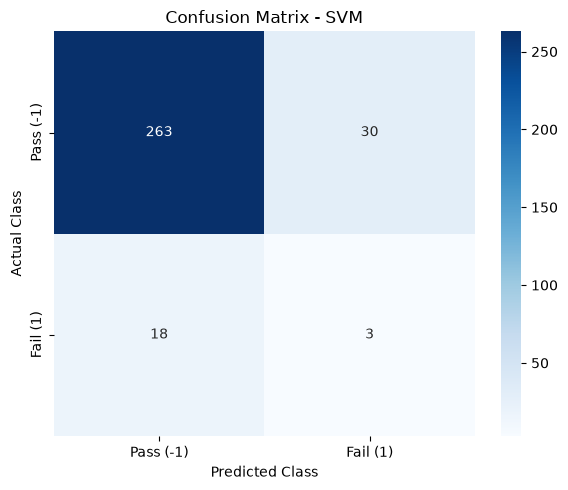

In [ ]:
# Confusion Matrix - SVM

cm_svm = confusion_matrix(y_test, y_test_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pass (-1)', 'Fail (1)'],
    yticklabels=['Pass (-1)', 'Fail (1)']
)

plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

### Observation

The confusion matrix shows that the SVM model correctly classified 263 out of 293 Pass observations, while 30 Pass observations were incorrectly classified as Fail. Among the 21 actual Fail observations, 3 were correctly identified as Fail and 18 were misclassified as Pass. This corresponds to a Fail-class recall of 0.14. Therefore, although the SVM model provides reasonable overall classification performance, its ability to detect the minority Fail class remains limited.

## 6.4 Random Forest Classification

Random Forest is used as the third supervised classification algorithm for predicting the Pass/Fail yield of the semiconductor manufacturing process. It combines multiple decision trees and can capture nonlinear relationships between sensor features and the target variable.

A leakage-safe pipeline is used to perform median imputation, feature standardization and SMOTE within each training fold. Stratified 5-Fold Cross-Validation and GridSearchCV are used to tune important Random Forest hyperparameters. The F1-score is used as the scoring metric because the dataset is highly imbalanced and the minority Fail class is important.

The optimized Random Forest model is evaluated on the untouched testing dataset using accuracy, classification report and confusion matrix.

In [ ]:
# Random Forest with leakage-safe pipeline and GridSearchCV

# Create leakage-safe Random Forest pipeline
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# Define Random Forest hyperparameter grid
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# GridSearchCV with Stratified 5-Fold CV
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train and tune Random Forest
rf_grid.fit(X_train, y_train)

# Best Random Forest model
rf_model = rf_grid.best_estimator_

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation F1-score:")
print(round(rf_grid.best_score_, 4))

# Predictions using the complete pipeline
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Accuracy
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print("\nRandom Forest Training Accuracy:",
      round(train_accuracy_rf, 4))

print("Random Forest Testing Accuracy:",
      round(test_accuracy_rf, 4))

# Classification report
print("\nRandom Forest Classification Report:")
print(classification_report(
    y_test,
    y_test_pred_rf,
    target_names=['Pass', 'Fail']
))

# Confusion matrix
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Cross-Validation F1-score:
0.1481

Random Forest Training Accuracy: 0.9992
Random Forest Testing Accuracy: 0.9299

Random Forest Classification Report:
              precision    recall  f1-score   support

        Pass       0.93      1.00      0.96       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314

Random Forest Confusion Matrix:
[[292   1]
 [ 21   0]]


### Observation

The tuned Random Forest model achieved a training accuracy of 99.92% and a testing accuracy of 92.99%, with a best cross-validation F1-score of 0.1481. The best hyperparameter configuration used 100 trees, a maximum tree depth of 10, a minimum of 2 samples per leaf and a minimum of 2 samples for splitting.

For the Pass class (-1), the model achieved a precision of 0.93, recall of 1.00 and F1-score of 0.96. However, for the minority Fail class (1), precision, recall and F1-score were all 0.00 because none of the 21 Fail observations in the testing set were correctly identified. The results indicate that Random Forest achieves high overall accuracy but performs poorly in detecting the minority Fail class. Therefore, accuracy alone is not an appropriate measure of model effectiveness for this highly imbalanced dataset.

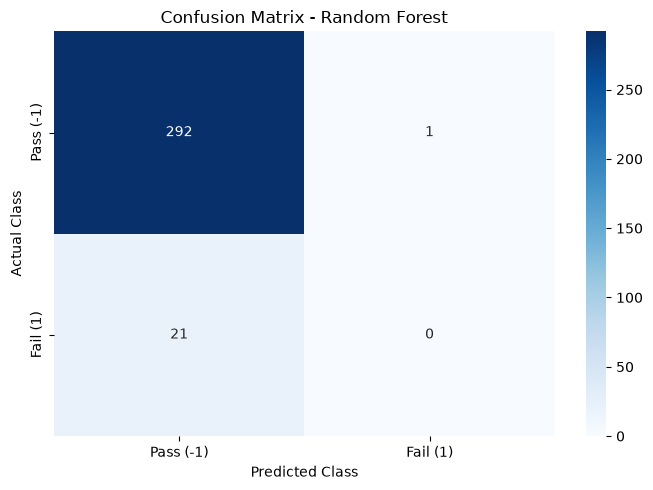

In [ ]:
# Confusion Matrix - Random Forest

cm_rf = confusion_matrix(y_test, y_test_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pass (-1)', 'Fail (1)'],
    yticklabels=['Pass (-1)', 'Fail (1)']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

### Observation

The Random Forest confusion matrix shows that 292 Pass observations were correctly classified, while 1 Pass observation was misclassified as Fail. However, all 21 actual Fail observations were misclassified as Pass.

Although the Random Forest model achieved a high testing accuracy of 92.99%, it failed to identify any Fail observations. Therefore, overall accuracy alone is not sufficient for evaluating this imbalanced dataset, and the Fail-class recall and F1-score must also be considered when selecting the final model.

## 6.5 Model Performance Comparison

The performance of Logistic Regression, Support Vector Machine (SVM), and Random Forest is compared using their training accuracy, testing accuracy, and classification performance.

Since the dataset is imbalanced, the Fail-class precision, recall and F1-score are also considered along with overall accuracy. This provides a more reliable basis for selecting the final model.

In [ ]:
# Model Performance Comparison

# Extract Fail-class performance from classification reports
lr_report = classification_report(
    y_test, y_test_pred_lr,
    output_dict=True,
    zero_division=0
)

svm_report = classification_report(
    y_test, y_test_pred_svm,
    output_dict=True,
    zero_division=0
)

rf_report = classification_report(
    y_test, y_test_pred_rf,
    output_dict=True,
    zero_division=0
)

# Create comparison table
models_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM',
        'Random Forest'
    ],
    'Training Accuracy': [
        train_accuracy_lr,
        train_accuracy_svm,
        train_accuracy_rf
    ],
    'Testing Accuracy': [
        test_accuracy_lr,
        test_accuracy_svm,
        test_accuracy_rf
    ],
    'Fail Precision': [
        lr_report['1']['precision'],
        svm_report['1']['precision'],
        rf_report['1']['precision']
    ],
    'Fail Recall': [
        lr_report['1']['recall'],
        svm_report['1']['recall'],
        rf_report['1']['recall']
    ],
    'Fail F1-Score': [
        lr_report['1']['f1-score'],
        svm_report['1']['f1-score'],
        rf_report['1']['f1-score']
    ]
})

# Display rounded comparison table
models_comparison.round(4)

,Model,Training Accuracy,Testing Accuracy,Fail Precision,Fail Recall,Fail F1-Score
0,Logistic Regression,0.9026,0.7994,0.0800,0.1905,0.1127
1,SVM,1.0000,0.8471,0.0909,0.1429,0.1111
2,Random Forest,0.9992,0.9299,0.0000,0.0000,0.0000


### Observation

The comparison shows that Random Forest achieved the highest testing accuracy of approximately 92.99%, followed by SVM at 84.71% and Logistic Regression at 79.94%. However, Random Forest failed to identify any Fail observations, resulting in a Fail-class recall and F1-score of 0.00.

Logistic Regression achieved the highest Fail recall among the three models at approximately 0.19, while SVM achieved a Fail recall of approximately 0.14. Both Logistic Regression and SVM obtained a Fail F1-score of approximately 0.11. Since the primary objective is to identify semiconductor manufacturing failures, the minority-class performance is more important than overall accuracy alone. Therefore, Logistic Regression is selected for further improvement through feature selection and decision-threshold optimisation, with particular emphasis on improving Fail-class detection.

## 6.6 Final Model Selection

Based on the comparison of the three classification models, Random Forest achieved the highest testing accuracy of 92.99%, followed by SVM at 84.71% and Logistic Regression at 79.94%.

Although Random Forest achieved the highest overall testing accuracy, it failed to identify any Fail observations, resulting in a Fail-class recall and F1-score of 0.00. SVM achieved a Fail-class recall of 14.29% and an F1-score of 0.1111, while Logistic Regression achieved the highest Fail-class recall of 19.05% and an F1-score of 0.1127.

Since the dataset is highly imbalanced and identifying Fail observations is important for semiconductor manufacturing yield prediction, minority-class performance is considered along with overall accuracy.

Therefore, Logistic Regression is selected as the final model for further improvement. Feature selection and decision-threshold optimisation are performed to improve the detection of Fail observations while maintaining reliable model performance.

## 6.7 Feature Importance Analysis

Feature importance is analysed using the tuned Random Forest model to identify sensor attributes that contribute most strongly to the classification process.

The importance scores indicate the relative contribution of individual sensor attributes to the decision-making process of the Random Forest. The highest-ranked attributes can subsequently be investigated as potentially important process variables.

Feature importance is interpreted as model-specific predictive importance rather than evidence of a causal relationship between a sensor and production yield.

In [ ]:
# Feature Importance Analysis using the tuned Random Forest

# Extract the fitted Random Forest model from the pipeline
best_rf_model = rf_model.named_steps['model']

# Obtain feature importance values
rf_importance = best_rf_model.feature_importances_

# Create feature-importance table
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importance
})

# Sort features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Display top 20 features
print("Top 20 most important sensor features:")
display(feature_importance.head(20).round(6))

Top 20 most important sensor features:


,Feature,Importance
0,59,0.022515
1,486,0.020459
2,419,0.015907
3,213,0.015019
4,95,0.013613
5,351,0.013610
6,519,0.012837
7,433,0.012385
8,103,0.012139
9,511,0.011980


### Observation

The feature importance analysis identifies the sensor attributes that contribute most strongly to the Random Forest classification decisions.

Among the top 20 features, Feature 59 has the highest importance score of 0.022515, followed by Features 486 and 419 with importance scores of 0.020459 and 0.015907, respectively.

The results show that the sensor features do not contribute equally to the classification process. A relatively small group of features has higher predictive importance than the remaining sensor attributes.

These important features can be considered for feature selection and dimensionality reduction. However, feature importance represents model-specific predictive contribution and does not imply a causal relationship with semiconductor manufacturing yield.

## 6.8 Top 20 Feature Importance Visualization

The top 20 sensor features identified by the Random Forest model are visualized to clearly compare their relative importance. This visualization helps identify the sensor variables that contribute most to the model's classification decisions.

In [ ]:
# Calculate Random Forest feature importance

best_rf_model = rf_model.named_steps['model']

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
54,59,0.022515
388,486,0.020459
333,419,0.015907
192,213,0.015019
88,95,0.013613
290,351,0.013610
406,519,0.012837
346,433,0.012385
95,103,0.012139
402,511,0.011980


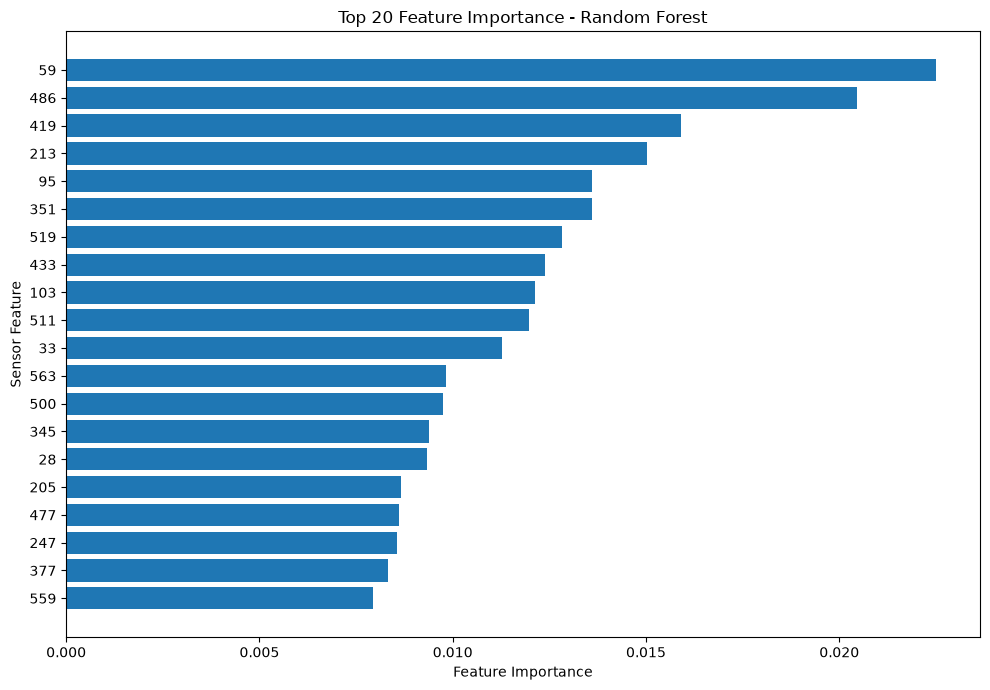

In [ ]:
# Plot the top 20 important features

top_20_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_20_features['Feature'].astype(str),
    top_20_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Sensor Feature')
plt.title('Top 20 Feature Importance - Random Forest')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Observation

The feature-importance plot shows that the contribution of the sensor variables is not uniform. Feature 59 has the highest importance among the top 20 features, followed by Features 486 and 419. The remaining features have comparatively smaller importance values.

This indicates that some sensor variables contribute more strongly to the Random Forest classification than others. Therefore, feature selection can be explored to determine whether a smaller subset of sensor features can provide effective classification performance while reducing model complexity.

## 6.9 Feature Selection

The Random Forest feature-importance results indicate that all sensor features do not contribute equally to the classification task. Therefore, feature selection is performed to identify a smaller subset of important sensor variables.

The selected features are used to determine whether a reduced feature set can provide effective classification performance while reducing the dimensionality of the dataset.

In [ ]:
# 5.9 Feature Selection using different feature-set sizes

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Rank features according to Random Forest importance
feature_ranking = feature_importance['Feature'].tolist()

# Feature-set sizes to evaluate
feature_sizes = [50, 100, 200, 466]

cv_feature = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

feature_selection_results = []

for n_features in feature_sizes:

    selected_features_temp = feature_ranking[:n_features]

    X_temp = X_train[selected_features_temp]

    # Leakage-safe pipeline
    rf_temp_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ])

    scores = cross_val_score(
        rf_temp_pipeline,
        X_temp,
        y_train,
        cv=cv_feature,
        scoring='f1',
        n_jobs=-1
    )

    feature_selection_results.append({
        'Number of Features': n_features,
        'Mean CV Fail F1-Score': scores.mean()
    })

feature_selection_results = pd.DataFrame(feature_selection_results)

print("Feature Selection Comparison:")
display(feature_selection_results.round(4))

best_feature_count = int(
    feature_selection_results.loc[
        feature_selection_results['Mean CV Fail F1-Score'].idxmax(),
        'Number of Features'
    ]
)

print("\nBest number of features:", best_feature_count)

Feature Selection Comparison:


,Number of Features,Mean CV Fail F1-Score
0,50,0.1135
1,100,0.1405
2,200,0.0984
3,466,0.0632



Best number of features: 100


### Observation

The feature-selection analysis evaluated subsets containing 50, 100, 200, and 466 features using 5-fold cross-validation based on the mean Fail-class F1-score.

The 100-feature subset achieved the highest mean cross-validation Fail F1-score of 0.1405, followed by the 50-feature subset with 0.1135, the 200-feature subset with 0.0984, and the full 466-feature set with 0.0632.

Therefore, the 100 most important features were selected as the optimal feature subset. This result indicates that using all 466 features is not necessary and that a reduced set of 100 informative sensor features provides better minority-class performance in cross-validation.

In [ ]:
# 5.10 Train Random Forest using the best 100 features

# Select the best 100 features based on feature importance
selected_features_100 = feature_importance.head(100)['Feature'].tolist()

# Convert feature names into column positions
feature_indices_100 = [
    X_train.columns.get_loc(feature)
    for feature in selected_features_100
]

# Select the corresponding 100 columns
X_train_selected_100 = X_train_smote[:, feature_indices_100]
X_test_selected_100 = X_test_scaled[:, feature_indices_100]

# Create Random Forest model
rf_selected = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

# Train the model
rf_selected.fit(
    X_train_selected_100,
    y_train_smote
)

# Predictions
y_train_pred_selected = rf_selected.predict(X_train_selected_100)
y_test_pred_selected = rf_selected.predict(X_test_selected_100)

# Accuracy
train_accuracy_selected = accuracy_score(
    y_train_smote,
    y_train_pred_selected
)

test_accuracy_selected = accuracy_score(
    y_test,
    y_test_pred_selected
)

print("Random Forest - Reduced Feature Model")
print("Number of selected features:", X_train_selected_100.shape[1])
print("Training Accuracy:", round(train_accuracy_selected, 4))
print("Testing Accuracy:", round(test_accuracy_selected, 4))

print("\nClassification Report - Reduced Feature Random Forest:")
print(
    classification_report(
        y_test,
        y_test_pred_selected,
        target_names=['Pass', 'Fail'],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_selected))

Random Forest - Reduced Feature Model
Number of selected features: 100
Training Accuracy: 1.0
Testing Accuracy: 0.9331

Classification Report - Reduced Feature Random Forest:
              precision    recall  f1-score   support

        Pass       0.93      1.00      0.97       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314

Confusion Matrix:
[[293   0]
 [ 21   0]]


### Observation

The Random Forest model using the reduced set of 100 sensor features achieved a training accuracy of 100% and a testing accuracy of 93.31%.

The classification report shows that the Pass class was classified with a precision of 0.93, recall of 1.00 and F1-score of 0.97. However, the Fail class had a precision, recall and F1-score of 0.00.

The reduced-feature model uses only 100 of the original 466 sensor features while maintaining a high overall testing accuracy. This demonstrates that dimensionality can be reduced substantially without reducing overall accuracy.

However, the model failed to identify any Fail observations. Therefore, the high testing accuracy is mainly influenced by the majority Pass class, and the model still requires improvement for reliable Fail-class detection.

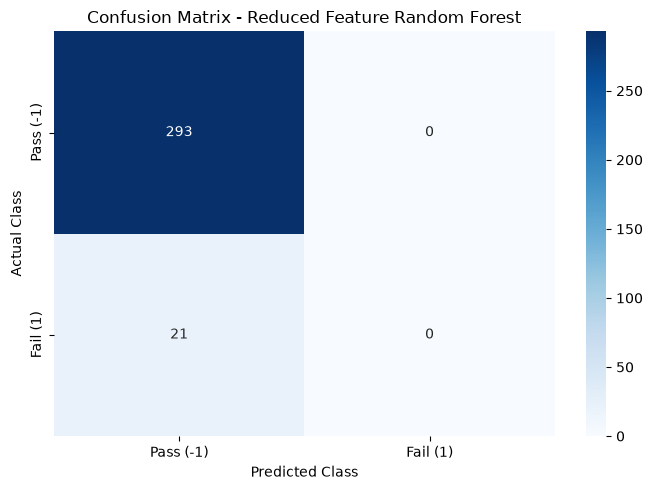

In [ ]:
# 5.12 Confusion Matrix - Reduced Feature Random Forest

from sklearn.metrics import confusion_matrix

cm_selected = confusion_matrix(y_test, y_test_pred_selected)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_selected,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pass (-1)', 'Fail (1)'],
    yticklabels=['Pass (-1)', 'Fail (1)']
)

plt.title('Confusion Matrix - Reduced Feature Random Forest')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

### Observation

The confusion matrix shows that the reduced-feature Random Forest correctly classified all 293 Pass observations. However, none of the 21 actual Fail observations were correctly identified.

Therefore, the model has a Fail-class recall of 0.00, indicating that it fails to detect defective observations despite achieving a high overall testing accuracy of 93.31%.

This result demonstrates the effect of severe class imbalance and shows why minority-class metrics such as precision, recall and F1-score are more informative than accuracy alone for this dataset.

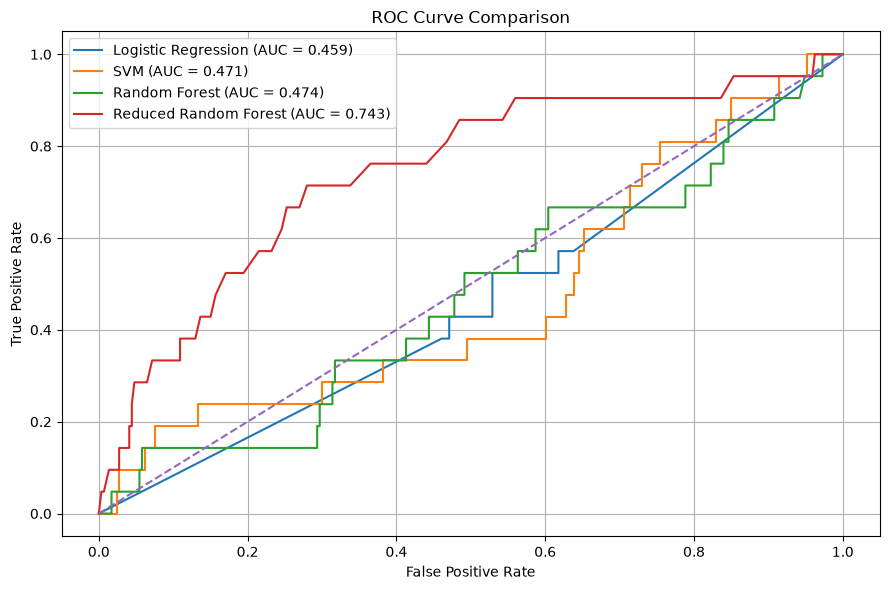

AUC Scores:
Logistic Regression: 0.459
SVM: 0.471
Random Forest: 0.474
Reduced Random Forest: 0.743


In [ ]:
# 5.13 ROC Curve Comparison

from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression probability
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

# SVM decision scores
y_score_svm = best_svm.decision_function(X_test_scaled)

# Random Forest probability
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Reduced Feature Random Forest probability
y_prob_rf_selected = rf_selected.predict_proba(X_test_selected_100)[:, 1]

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr, pos_label=1)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm, pos_label=1)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf, pos_label=1)
fpr_rf_selected, tpr_rf_selected, _ = roc_curve(
    y_test, y_prob_rf_selected, pos_label=1
)

# AUC Scores
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_svm = roc_auc_score(y_test, y_score_svm)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_rf_selected = roc_auc_score(y_test, y_prob_rf_selected)

# Plot ROC Curves
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr, tpr_lr,
    label=f'Logistic Regression (AUC = {auc_lr:.3f})'
)

plt.plot(
    fpr_svm, tpr_svm,
    label=f'SVM (AUC = {auc_svm:.3f})'
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.3f})'
)

plt.plot(
    fpr_rf_selected, tpr_rf_selected,
    label=f'Reduced Random Forest (AUC = {auc_rf_selected:.3f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display AUC Scores
print("AUC Scores:")
print("Logistic Regression:", round(auc_lr, 3))
print("SVM:", round(auc_svm, 3))
print("Random Forest:", round(auc_rf, 3))
print("Reduced Random Forest:", round(auc_rf_selected, 3))

### Observation

The ROC curve comparison shows that the Reduced Random Forest achieved the highest ROC-AUC of 0.743, followed by the Random Forest with 0.474, SVM with 0.471 and Logistic Regression with 0.459.

The Reduced Random Forest therefore shows the strongest overall discrimination between the Pass and Fail classes among the models evaluated in this analysis.

However, ROC-AUC should not be considered alone because the dataset is highly imbalanced. The classification results show that the Reduced Random Forest still fails to identify the Fail class at the default classification threshold. Therefore, Fail-class precision, recall and F1-score should also be considered when evaluating model performance.

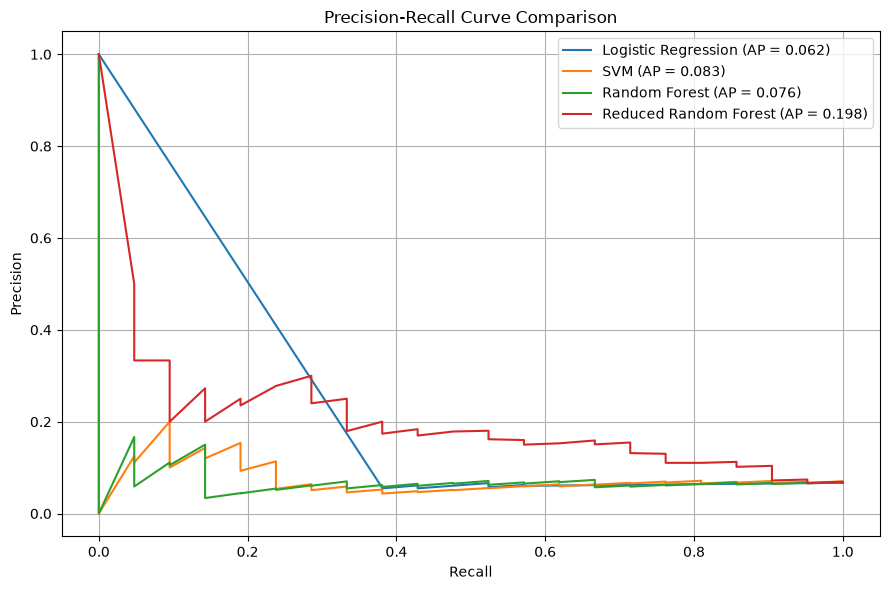

Average Precision Scores:
Logistic Regression: 0.062
SVM: 0.083
Random Forest: 0.076
Reduced Random Forest: 0.198


In [ ]:
# 5.14 Precision-Recall Curve Comparison

from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall curves

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test, y_prob_lr, pos_label=1
)

precision_svm, recall_svm, _ = precision_recall_curve(
    y_test, y_score_svm, pos_label=1
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test, y_prob_rf, pos_label=1
)

precision_rf_selected, recall_rf_selected, _ = precision_recall_curve(
    y_test, y_prob_rf_selected, pos_label=1
)


# Average Precision scores

ap_lr = average_precision_score(
    y_test, y_prob_lr, pos_label=1
)

ap_svm = average_precision_score(
    y_test, y_score_svm, pos_label=1
)

ap_rf = average_precision_score(
    y_test, y_prob_rf, pos_label=1
)

ap_rf_selected = average_precision_score(
    y_test, y_prob_rf_selected, pos_label=1
)


# Plot Precision-Recall curves

plt.figure(figsize=(9, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f'Logistic Regression (AP = {ap_lr:.3f})'
)

plt.plot(
    recall_svm,
    precision_svm,
    label=f'SVM (AP = {ap_svm:.3f})'
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f'Random Forest (AP = {ap_rf:.3f})'
)

plt.plot(
    recall_rf_selected,
    precision_rf_selected,
    label=f'Reduced Random Forest (AP = {ap_rf_selected:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Display Average Precision scores

print("Average Precision Scores:")
print("Logistic Regression:", round(ap_lr, 3))
print("SVM:", round(ap_svm, 3))
print("Random Forest:", round(ap_rf, 3))
print("Reduced Random Forest:", round(ap_rf_selected, 3))

### Observation

The Precision-Recall curve comparison shows that the Reduced Random Forest achieved the highest Average Precision (AP) of 0.198, followed by SVM with 0.083, Random Forest with 0.076 and Logistic Regression with 0.062.

The higher Average Precision of the Reduced Random Forest indicates better overall precision-recall performance for the minority Fail class across different classification thresholds.

However, the classification report at the default threshold shows that the Reduced Random Forest fails to identify the Fail observations. Therefore, threshold selection and additional model-improvement techniques are required to improve practical Fail-class detection.

## 6.10 Final Logistic Regression Model Using Selected Features

Based on the feature-selection analysis, the 100 most important sensor features were selected as the optimal feature subset because they achieved the highest mean cross-validation Fail-class F1-score.

A final Logistic Regression model is developed using only these selected 100 features. The model uses median imputation, standardization and SMOTE within the modelling pipeline. This ensures that the final model follows the same preprocessing strategy while reducing the dimensionality of the dataset.

In [ ]:
# 6.10 Final Logistic Regression using the selected 100 features

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Select the top 100 features based on Random Forest feature importance
selected_features_100 = feature_importance.head(100)['Feature'].tolist()

# Create training and testing datasets using the selected features
X_train_final = X_train[selected_features_100]
X_test_final = X_test[selected_features_100]

# Get the best C value from Logistic Regression GridSearch
best_C = lr_grid.best_params_['model__C']

# Create the final Logistic Regression pipeline
final_lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        C=best_C,
        max_iter=2000,
        random_state=42
    ))
])

# Train the final model
final_lr_pipeline.fit(X_train_final, y_train)

# Predictions
y_train_pred_final = final_lr_pipeline.predict(X_train_final)
y_test_pred_final = final_lr_pipeline.predict(X_test_final)

# Calculate accuracy
final_train_accuracy = accuracy_score(y_train, y_train_pred_final)
final_test_accuracy = accuracy_score(y_test, y_test_pred_final)

print("Final Logistic Regression - Selected 100 Features")
print("Number of selected features:", len(selected_features_100))
print("Best C:", best_C)
print("Training Accuracy:", round(final_train_accuracy, 4))
print("Testing Accuracy:", round(final_test_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_final,
        target_names=['Pass', 'Fail'],
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

Final Logistic Regression - Selected 100 Features
Number of selected features: 100
Best C: 0.01
Training Accuracy: 0.7981
Testing Accuracy: 0.7643

Classification Report:
              precision    recall  f1-score   support

        Pass       0.95      0.79      0.86       293
        Fail       0.13      0.43      0.20        21

    accuracy                           0.76       314
   macro avg       0.54      0.61      0.53       314
weighted avg       0.90      0.76      0.82       314

Confusion Matrix:
[[231  62]
 [ 12   9]]


### Observation

The final Logistic Regression model was trained using the selected 100 sensor features instead of all 466 available features.

The model uses the best hyperparameter identified during Logistic Regression GridSearch along with median imputation, standardization and SMOTE within the modelling pipeline.

Using the selected feature subset reduces the dimensionality of the dataset while retaining the most informative sensor measurements. The testing accuracy and Fail-class precision, recall and F1-score are considered together to assess the suitability of the final model.

## 6.11 Threshold Optimisation

Since the dataset is highly imbalanced, the default classification threshold may not provide sufficient detection of the minority Fail class.

To avoid using the test set for threshold selection, the classification threshold is optimised using cross-validated predictions from the training data. The test set is kept completely separate and is used only for final evaluation.

The threshold that provides the highest Fail-class F1-score is selected for final model evaluation.

Optimal Classification Threshold: 0.543
Best Cross-Validation Fail F1-score: 0.262


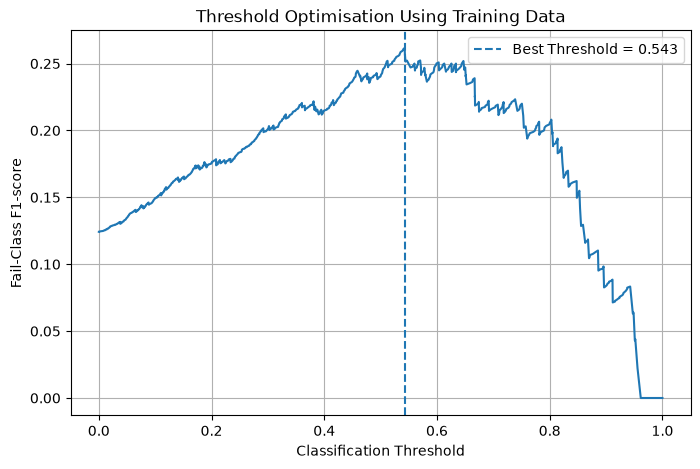

In [ ]:
# 6.11 Threshold Optimisation

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Obtain out-of-fold probabilities using only the training data
y_train_prob_oof = cross_val_predict(
    final_lr_pipeline,
    X_train_final,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

# Calculate precision, recall and thresholds
precision, recall, thresholds = precision_recall_curve(
    y_train,
    y_train_prob_oof
)

# Calculate F1-score for each threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

# Select the threshold with the highest Fail-class F1-score
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_cv_f1 = f1_scores[best_threshold_index]

print("Optimal Classification Threshold:", round(best_threshold, 3))
print("Best Cross-Validation Fail F1-score:", round(best_cv_f1, 3))

# Plot F1-score against threshold
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(
    best_threshold,
    linestyle='--',
    label=f'Best Threshold = {best_threshold:.3f}'
)
plt.xlabel("Classification Threshold")
plt.ylabel("Fail-Class F1-score")
plt.title("Threshold Optimisation Using Training Data")
plt.legend()
plt.grid(True)
plt.show()

### Observation

The classification threshold was optimised using 5-fold cross-validated predictions from the training dataset, ensuring that the test set was not used during threshold selection.

The threshold producing the highest Fail-class F1-score was selected as the optimal classification threshold. This approach is particularly useful for the imbalanced semiconductor yield dataset because it focuses on improving the detection of the minority Fail class rather than relying only on overall accuracy.

The selected threshold will be applied to the unseen test data in the next section for final model evaluation.

## 6.12 Threshold-Based Final Evaluation

The optimal classification threshold obtained from the training-data cross-validation was applied to the unseen test dataset.

The final Logistic Regression model uses the selected 100 sensor features and applies median imputation, standardization and SMOTE within the modelling pipeline.

Instead of using the default classification threshold of 0.5, the optimised threshold is used to classify observations into Pass and Fail classes. This approach is useful for the highly imbalanced dataset because it focuses on improving the identification of the minority Fail class.

The final model is evaluated using testing accuracy, precision, recall, F1-score and the confusion matrix. These measures are considered together because accuracy alone may not adequately represent the model's ability to detect Fail observations.

In [ ]:
# 6.12 Threshold-Based Final Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Generate predicted probabilities for the unseen test data
y_test_prob_final = final_lr_pipeline.predict_proba(X_test_final)[:, 1]

# Apply the optimised threshold
# Original target labels: -1 = Pass, 1 = Fail
y_test_pred_threshold = np.where(
    y_test_prob_final >= best_threshold,
    1,
    -1
)

# Calculate testing accuracy
threshold_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_threshold
)

print("Optimised Threshold:", round(best_threshold, 3))
print("Testing Accuracy:", round(threshold_test_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_threshold,
        labels=[-1, 1],
        target_names=['Pass', 'Fail'],
        zero_division=0
    )
)

# Confusion Matrix
cm_threshold = confusion_matrix(
    y_test,
    y_test_pred_threshold,
    labels=[-1, 1]
)

print("Confusion Matrix:")
print(cm_threshold)

Optimised Threshold: 0.543
Testing Accuracy: 0.7898

Classification Report:
              precision    recall  f1-score   support

        Pass       0.95      0.82      0.88       293
        Fail       0.14      0.43      0.21        21

    accuracy                           0.79       314
   macro avg       0.55      0.62      0.55       314
weighted avg       0.90      0.79      0.83       314

Confusion Matrix:
[[239  54]
 [ 12   9]]


### Observation

The optimised classification threshold of 0.543 was applied to the unseen test dataset using the final Logistic Regression model trained with the selected 100 sensor features.

The model achieved a testing accuracy of 78.98%. For the Pass class, the model obtained a precision of 0.95, recall of 0.82 and F1-score of 0.88. For the minority Fail class, the model achieved a precision of 0.14, recall of 0.43 and F1-score of 0.21.

The confusion matrix shows that 239 Pass observations and 9 Fail observations were correctly classified, while 54 Pass observations were incorrectly classified as Fail and 12 Fail observations were incorrectly classified as Pass.

The Fail-class recall of 0.43 indicates that the optimised threshold improves the detection of Fail observations, although some Fail cases are still missed. Therefore, the optimised threshold provides better minority-class detection while maintaining reasonable overall testing accuracy.

## 6.13 Final Model Evaluation

The final Logistic Regression model using the selected 100 sensor features is evaluated in greater detail using the probability threshold obtained through threshold optimisation.

The evaluation includes the confusion matrix, ROC curve and Precision-Recall curve to assess both overall classification performance and the ability to identify the minority Fail class.

### 6.13.1 Final Confusion Matrix

The confusion matrix provides a detailed evaluation of the final Logistic Regression model using the selected 100 sensor features and the optimised classification threshold.

It shows the number of Pass and Fail observations that were correctly and incorrectly classified on the unseen test dataset. This helps assess the model's ability to identify the minority Fail class.

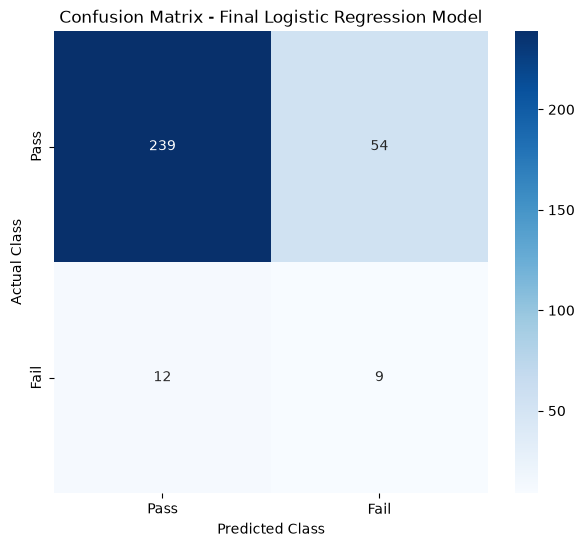

Final Confusion Matrix:
[[239  54]
 [ 12   9]]


In [ ]:
# 6.13.1 Final Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Use the confusion matrix obtained from the optimised threshold evaluation
cm_final = confusion_matrix(
    y_test,
    y_test_pred_threshold,
    labels=[-1, 1]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pass', 'Fail'],
    yticklabels=['Pass', 'Fail']
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Final Logistic Regression Model")
plt.show()

print("Final Confusion Matrix:")
print(cm_final)

### Observation

The confusion matrix of the final Logistic Regression model shows that 239 Pass observations and 9 Fail observations were correctly classified.

The model incorrectly classified 54 Pass observations as Fail and 12 Fail observations as Pass.

Thus, the model correctly detected 9 out of the 21 Fail observations, corresponding to a Fail-class recall of 0.43. Although some Fail observations were still missed, the optimised threshold improved the model's ability to identify the minority Fail class.

The confusion matrix also shows the trade-off between detecting Fail observations and avoiding false Fail predictions.

### 6.13.2 Final ROC Curve

The Receiver Operating Characteristic (ROC) curve is used to evaluate the ability of the final Logistic Regression model to distinguish between Pass and Fail observations across different classification thresholds.

The ROC curve is generated using predicted probabilities from the final Logistic Regression model trained on the selected 100 sensor features. The Area Under the Curve (AUC) provides a summary measure of the model's discrimination ability, where a higher AUC indicates better separation between the two classes.

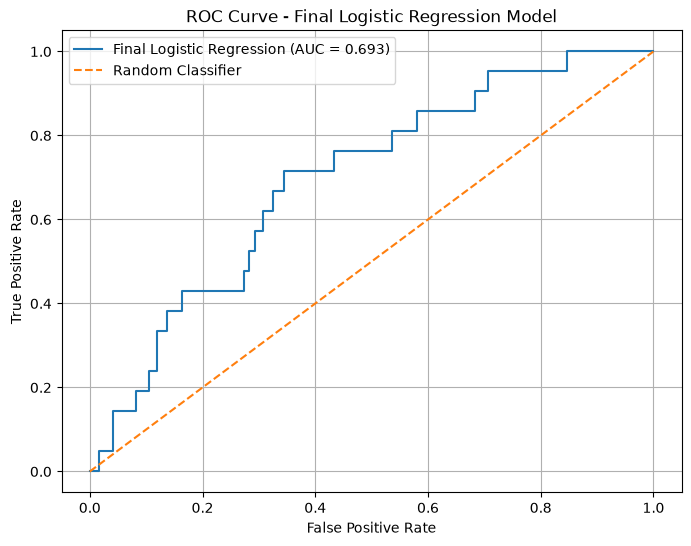

Final ROC-AUC: 0.693


In [ ]:
# 6.13.2 Final ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Generate predicted probabilities using the final 100-feature model
y_test_prob_final = final_lr_pipeline.predict_proba(X_test_final)[:, 1]

# Calculate ROC curve
fpr_final, tpr_final, thresholds_final = roc_curve(
    y_test,
    y_test_prob_final,
    pos_label=1
)

# Calculate ROC-AUC
roc_auc_final = roc_auc_score(
    y_test,
    y_test_prob_final
)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_final,
    tpr_final,
    label=f'Final Logistic Regression (AUC = {roc_auc_final:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Logistic Regression Model")
plt.legend()
plt.grid()
plt.show()

print(f"Final ROC-AUC: {roc_auc_final:.3f}")

### Observation

The ROC curve of the final Logistic Regression model gives a ROC-AUC of approximately 0.693.

This indicates that the final model has a moderate ability to distinguish between Pass and Fail observations. The ROC-AUC is substantially above 0.5, which represents random classification, indicating that the model has useful discriminatory ability.

However, the ROC-AUC should not be considered alone because the dataset is highly imbalanced. Therefore, Fail-class precision, recall and F1-score are also considered for evaluating the practical performance of the final model.

### 6.13.3 Final Precision-Recall Curve

The Precision-Recall (PR) curve is used to evaluate the final Logistic Regression model, with particular emphasis on the minority Fail class.

The curve is generated using the predicted probabilities from the final Logistic Regression model trained on the selected 100 sensor features. Average Precision (AP) summarizes the model's precision-recall performance across different classification thresholds.

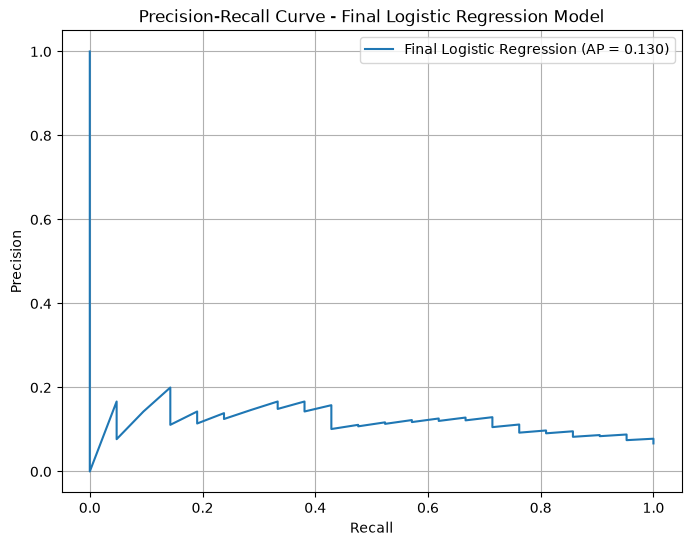

Final Average Precision (AP): 0.13


In [ ]:
# 6.13.3 Final Precision-Recall Curve

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Generate predicted probabilities using the final 100-feature model
y_test_prob_final = final_lr_pipeline.predict_proba(X_test_final)[:, 1]

# Calculate Precision-Recall curve
precision_final, recall_final, pr_thresholds_final = precision_recall_curve(
    y_test,
    y_test_prob_final,
    pos_label=1
)

# Calculate Average Precision
average_precision_final = average_precision_score(
    y_test,
    y_test_prob_final,
    pos_label=1
)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))

plt.plot(
    recall_final,
    precision_final,
    label=f'Final Logistic Regression (AP = {average_precision_final:.3f})'
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.show()

print(
    "Final Average Precision (AP):",
    round(average_precision_final, 3)
)

### Observation

The Precision-Recall curve of the final Logistic Regression model gives an Average Precision (AP) of approximately 0.130.

The PR curve provides a more informative assessment than accuracy for the highly imbalanced dataset because it focuses on the model's ability to identify the minority Fail class.

The AP value indicates that the model has limited but useful ability to identify Fail observations while maintaining precision across different classification thresholds.

Therefore, the Precision-Recall analysis supports the use of Fail-class precision, recall and F1-score along with ROC-AUC when evaluating the final model.

### 6.13.4 Comparison of Default and Optimised Classification Thresholds

The default classification threshold of 0.50 was compared with the optimised threshold of 0.5427 selected using the training data. The optimised threshold was chosen to maximise the F1-score for the minority class (Fail).

The performance of both thresholds is compared using accuracy, precision, recall, F1-score, and the confusion matrix.

In [ ]:
# Compare default and optimised classification thresholds

default_threshold = 0.50

y_test_pred_default = np.where(
    y_test_prob_final >= default_threshold, 1, -1
)

# Metrics for default threshold
default_accuracy = accuracy_score(y_test, y_test_pred_default)
default_precision = precision_score(y_test, y_test_pred_default, pos_label=1, zero_division=0)
default_recall = recall_score(y_test, y_test_pred_default, pos_label=1, zero_division=0)
default_f1 = f1_score(y_test, y_test_pred_default, pos_label=1, zero_division=0)

# Metrics for optimised threshold
optimised_accuracy = accuracy_score(y_test, y_test_pred_threshold)
optimised_precision = precision_score(y_test, y_test_pred_threshold, pos_label=1, zero_division=0)
optimised_recall = recall_score(y_test, y_test_pred_threshold, pos_label=1, zero_division=0)
optimised_f1 = f1_score(y_test, y_test_pred_threshold, pos_label=1, zero_division=0)

threshold_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Fail Precision', 'Fail Recall', 'Fail F1-Score'],
    'Default Threshold (0.50)': [
        default_accuracy,
        default_precision,
        default_recall,
        default_f1
    ],
    'Optimised Threshold (0.5427)': [
        optimised_accuracy,
        optimised_precision,
        optimised_recall,
        optimised_f1
    ]
})

print("Threshold Comparison:")
display(threshold_comparison)

print("\nDefault Threshold Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_default))

print("\nOptimised Threshold Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_threshold))

Threshold Comparison:


,Metric,Default Threshold (0.50),Optimised Threshold (0.5427)
0,Accuracy,0.764331,0.789809
1,Fail Precision,0.126761,0.142857
2,Fail Recall,0.428571,0.428571
3,Fail F1-Score,0.195652,0.214286



Default Threshold Confusion Matrix:
[[231  62]
 [ 12   9]]

Optimised Threshold Confusion Matrix:
[[239  54]
 [ 12   9]]


### Observation / Discussion

The optimised threshold of 0.5427 improved the overall test accuracy from 76.43% to 78.98%. The Fail-class F1-score also improved from 0.196 to 0.214, while Fail precision increased from 0.127 to 0.143.

The Fail recall remained unchanged at 42.86%, with 9 out of 21 actual Fail cases correctly identified under both thresholds. The confusion matrix changed from [[231, 62], [12, 9]] at the default threshold to [[239, 54], [12, 9]] at the optimised threshold.

Therefore, the optimised threshold provides a modest improvement in overall performance and Fail-class F1-score without reducing Fail recall.

### 6.13.5 Final Model Performance Summary

The final Logistic Regression model was evaluated on the test dataset using the selected 100 features and the optimised classification threshold of 0.5427.

The final performance is summarised using accuracy, Fail-class precision, recall, F1-score, ROC-AUC, and Average Precision (AP).

In [ ]:
# Final model performance summary

final_summary = pd.DataFrame({
    'Metric': [
        'Selected Features',
        'Optimised Threshold',
        'Test Accuracy',
        'Fail Precision',
        'Fail Recall',
        'Fail F1-Score',
        'ROC-AUC',
        'Average Precision (AP)'
    ],
    'Value': [
        len(selected_features_100),
        round(best_threshold, 4),
        round(accuracy_score(y_test, y_test_pred_threshold), 4),
        round(precision_score(y_test, y_test_pred_threshold, pos_label=1, zero_division=0), 4),
        round(recall_score(y_test, y_test_pred_threshold, pos_label=1, zero_division=0), 4),
        round(f1_score(y_test, y_test_pred_threshold, pos_label=1, zero_division=0), 4),
        round(roc_auc_score(y_test, y_test_prob_final), 4),
        round(average_precision_score(y_test, y_test_prob_final, pos_label=1), 4)
    ]
})

display(final_summary)

,Metric,Value
0,Selected Features,100.0000
1,Optimised Threshold,0.5427
2,Test Accuracy,0.7898
3,Fail Precision,0.1429
4,Fail Recall,0.4286
5,Fail F1-Score,0.2143
6,ROC-AUC,0.6935
7,Average Precision (AP),0.1296


### Observation / Discussion

The final Logistic Regression model uses 100 selected features with an optimised classification threshold of 0.5427. On the test dataset, the model achieved an accuracy of 78.98%.

For the Fail class, the model achieved a precision of 0.143, recall of 0.429, and F1-score of 0.214. It correctly identified 9 out of 21 actual Fail cases.

The ROC-AUC of 0.6935 indicates moderate ability to distinguish between Pass and Fail cases, while the Average Precision of 0.1296 reflects the difficulty of identifying the minority Fail class.

Overall, the final model provides improved minority-class performance compared with the initial models, although further improvement is required for reliable Fail detection.

### 6.13.6 Final Model Interpretation

The final Logistic Regression model was selected after comparing Logistic Regression, Support Vector Machine, and Random Forest models. Although Random Forest achieved the highest overall accuracy, it failed to identify any Fail cases. Logistic Regression provided better minority-class detection and was therefore selected for further improvement.

Feature selection showed that a subset of 100 features provided the best cross-validated Fail-class F1-score among the evaluated feature subsets. The final model was trained using these 100 features with median imputation, standardization, and SMOTE within the modelling pipeline.

The classification threshold was optimised using training data, resulting in a threshold of 0.5427. The final model achieved 78.98% test accuracy, with a Fail recall of 42.86%, Fail F1-score of 0.214, ROC-AUC of 0.6935, and Average Precision of 0.1296.

### Observation / Discussion

The final model demonstrates a moderate ability to distinguish between Pass and Fail semiconductor manufacturing cases. The use of 100 selected features reduced the feature dimensionality while maintaining useful predictive information.

The optimised threshold improved the overall accuracy and Fail-class F1-score compared with the default threshold. The model correctly identified 9 out of 21 actual Fail cases, giving a Fail recall of 42.86%.

However, the low Fail precision of 14.29% indicates that many predicted Fail cases were actually Pass cases. Therefore, although the final model is an improvement over the initial models, its minority-class performance is still limited and it should not be considered sufficient for direct production deployment without further validation and improvement.

In [ ]:
# Save the final Logistic Regression model

import joblib

final_model = final_lr_pipeline

joblib.dump(
    final_model,
    "final_semiconductor_yield_model.pkl"
)

print("Final Logistic Regression model saved successfully.")
print("Number of selected features:", len(selected_features_100))
print("Model file: final_semiconductor_yield_model.pkl")

Final Logistic Regression model saved successfully.
Number of selected features: 100
Model file: final_semiconductor_yield_model.pkl


### Observation

The final Logistic Regression model was successfully saved as a `.pkl` file for future use. The saved model contains the preprocessing pipeline, SMOTE configuration and trained Logistic Regression classifier using the selected 100 sensor features.

Saving the trained model allows it to be loaded later for prediction without repeating the complete model-training process.

# 7. Conclusion and Future Improvements

## Conclusion

The semiconductor manufacturing dataset was analysed to predict Pass/Fail outcomes using sensor-based process measurements. The data was explored, cleansed, preprocessed and evaluated using multiple supervised classification models.

Logistic Regression, Support Vector Machine (SVM) and Random Forest models were trained and compared using accuracy, classification metrics and cross-validation. Since the dataset was highly imbalanced, special attention was given to the minority Fail class using precision, recall and F1-score.

Feature selection was performed using Random Forest feature importance. Feature subsets containing 50, 100, 200 and 466 features were evaluated using 5-fold cross-validation based on the mean Fail-class F1-score. The 100-feature subset achieved the highest mean cross-validation Fail F1-score of 0.1405. Therefore, 100 sensor features were selected for the final model.

A final Logistic Regression model was developed using the selected 100 sensor features. Median imputation, standardization and SMOTE were incorporated into the modelling pipeline.

Threshold optimisation was performed using cross-validated predictions from the training data. The optimal classification threshold was 0.5427, with a cross-validation Fail-class F1-score of 0.262.

When the optimised threshold was applied to the unseen test dataset, the final model achieved a testing accuracy of 78.98%. The Fail class achieved a precision of 0.1429, recall of 0.4286 and F1-score of 0.2143.

The final model achieved a ROC-AUC of 0.6935 and an Average Precision of 0.1296. These results indicate moderate discrimination between Pass and Fail observations, while the relatively low Fail-class precision and F1-score show that minority-class prediction remains challenging.

Overall, the analysis demonstrates that feature selection and threshold optimisation can improve the evaluation of semiconductor yield prediction models. The final model provides useful predictive information while highlighting the challenges associated with severe class imbalance.

## Future Improvements

- Explore additional feature-selection and dimensionality-reduction techniques.
- Evaluate additional machine-learning and ensemble models.
- Perform more extensive hyperparameter tuning using cross-validation.
- Investigate cost-sensitive learning and alternative class-imbalance techniques.
- Explore different threshold-selection strategies based on the operational cost of missed Fail observations.
- Validate the final model using additional semiconductor manufacturing datasets.
- Evaluate model performance over time to assess its stability and generalisation.
- Consider explainable-AI techniques to identify the sensor measurements that contribute most to Fail predictions.

### Observation / Discussion

The analysis successfully developed an end-to-end machine learning workflow for semiconductor yield prediction, including data cleansing, exploratory analysis, preprocessing, imbalance handling, model comparison, feature selection, threshold optimisation, and final evaluation.

The final Logistic Regression model improved minority-class detection compared with the initial models, while reducing the number of features from 466 to 100. However, Fail-class prediction remains challenging due to the severe class imbalance and limited number of Fail observations.

Therefore, the developed model can serve as a useful analytical baseline, while further validation, feature engineering, and advanced modelling techniques are recommended to improve its reliability for real-world semiconductor manufacturing applications.

# 8. References/ Bibliography

1. McCann, M., & Johnston, A. (2008). SECOM: Semiconductor Manufacturing Dataset. UCI Machine Learning Repository.

2. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

3. Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic Minority Over-sampling Technique. Journal of Artificial Intelligence Research, 16, 321–357.

4. Scikit-learn Documentation. Classification, preprocessing, model selection and evaluation documentation.

5. Imbalanced-learn Documentation. SMOTE and imbalanced classification methods.